# URL Multiclass — Benchmark contrôlé entre familles de modèles

Ce notebook compare notre meilleure référence linéaire **LR-V2** à deux familles non linéaires adaptées aux données tabulaires :

1. `HistGradientBoostingClassifier` ;
2. `ExtraTreesClassifier`.

L'objectif n'est pas de lancer une recherche massive d'hyperparamètres.

Nous voulons répondre à une question simple :

> **une famille de modèles non linéaire peut-elle dépasser de manière robuste notre Logistic Regression V2 sur exactement les mêmes données et les mêmes groupes ?**

---

## Référence linéaire

La référence actuelle est :

`LR-V2 = log1p + StandardScaler + LogisticRegression(class_weight="balanced")`

Résultats précédemment validés :

- macro-F1 CV ≈ `0.8154 ± 0.0279` ;
- macro-F1 OOF ≈ `0.8194` ;
- F1 phishing OOF ≈ `0.8209` ;
- F1 malware OOF ≈ `0.8259` ;
- `phishing → benign` OOF ≈ `18.14 %`.

---

# Configurations comparées

| Configuration | Famille | Features | Scaling | Weighting |
|---|---|---|---|---|
| LR-V2 | Logistic Regression | `log1p` | StandardScaler | balanced |
| HGB-RAW | HistGradientBoosting | raw | aucun | balanced |
| HGB-LOG | HistGradientBoosting | `log1p` | aucun | balanced |
| ET-RAW | ExtraTrees | raw | aucun | balanced |
| ET-LOG | ExtraTrees | `log1p` | aucun | balanced |

Les variantes raw/log1p des modèles arbres permettent de vérifier empiriquement si les transformations validées pour le modèle linéaire apportent aussi un avantage aux modèles non linéaires.

---

# Protocole expérimental

Nous conservons exactement les règles des notebooks précédents :

- même snapshot ML ;
- même quarantaine des groupes multi-labels ;
- même split externe 80/20 historique ;
- test externe verrouillé ;
- mêmes 5 folds internes `StratifiedGroupKFold` ;
- aucune fuite de `group_key` ;
- full train dans chaque fold ;
- mêmes métriques ;
- mêmes prédictions OOF.

Le test externe n'est pas utilisé pour sélectionner une famille de modèle.

La sélection se fait uniquement sur la cross-validation interne group-aware.

## 0. Principes de sécurité, performance et reproductibilité

### Sécurité

Le notebook ne charge ni :

- URL brute ;
- hostname ;
- hash ;
- metadata source.

`sample_id` et `group_key` ne sont utilisés que pour les contrôles structurels et ne deviennent jamais des features.

Aucune valeur individuelle de `group_key` n'est affichée.

PostgreSQL est utilisé en lecture seule.

### Performance

Nous évitons volontairement :

- GridSearch massif ;
- centaines de configurations ;
- modèles externes lourds ;
- parallélisme illimité.

`ExtraTrees` utilise un nombre de workers plafonné.

### HistGradientBoosting

`early_stopping=False` est imposé pour cette comparaison.

La validation externe au modèle est déjà assurée par nos folds group-aware. Utiliser l'early stopping automatique créerait une seconde partition interne et compliquerait inutilement la garantie d'absence de fuite entre groupes.

### Reproductibilité

Seed global :

`42`

In [1]:
from __future__ import annotations

import os
import platform
import sys
import time
import warnings
from contextlib import contextmanager
from pathlib import Path

from dotenv import load_dotenv


def find_project_root() -> Path:
    current = Path.cwd().resolve()

    for candidate in (
        current,
        *current.parents,
    ):
        if (
            (candidate / "application").is_dir()
            and (candidate / "infrastructure").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Impossible de retrouver la racine du projet. "
        "Lancer Jupyter depuis le dépôt."
    )


PROJECT_ROOT = find_project_root()

load_dotenv(
    dotenv_path=PROJECT_ROOT / ".env",
    override=False,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

if not os.environ.get(
    "INGESTION_DATABASE_URL"
):
    raise RuntimeError(
        "INGESTION_DATABASE_URL n'est pas définie."
    )

print("Project root: détecté")
print(
    "INGESTION_DATABASE_URL: "
    "définie (valeur masquée)"
)

Project root: détecté
INGESTION_DATABASE_URL: définie (valeur masquée)


In [2]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import sklearn
    import sqlalchemy

    from IPython.display import display
    from sqlalchemy import text

    from sklearn.ensemble import (
        ExtraTreesClassifier,
        HistGradientBoostingClassifier,
    )
    from sklearn.exceptions import (
        ConvergenceWarning,
    )
    from sklearn.linear_model import (
        LogisticRegression,
    )
    from sklearn.metrics import (
        accuracy_score,
        average_precision_score,
        balanced_accuracy_score,
        classification_report,
        cohen_kappa_score,
        confusion_matrix,
        ConfusionMatrixDisplay,
        f1_score,
        jaccard_score,
        log_loss,
        matthews_corrcoef,
        precision_score,
        recall_score,
        roc_auc_score,
        top_k_accuracy_score,
    )
    from sklearn.model_selection import (
        StratifiedGroupKFold,
    )
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import (
        StandardScaler,
        label_binarize,
    )

    from infrastructure.persistence.sqlalchemy.engine import (
        create_ingestion_engine,
    )

except ImportError as exc:
    raise RuntimeError(
        "Une dépendance EDA/ML est manquante. "
        "Installer explicitement les dépendances "
        "du projet avant d'exécuter ce notebook."
    ) from exc


pd.set_option(
    "display.max_columns",
    140,
)
pd.set_option(
    "display.max_rows",
    140,
)
pd.set_option(
    "display.width",
    220,
)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("SQLAlchemy:", sqlalchemy.__version__)

Python: 3.12.6
pandas: 2.2.3
numpy: 2.2.6
matplotlib: 3.10.0
scikit-learn: 1.6.1
SQLAlchemy: 2.0.51


## 1. Constantes du benchmark

Nous reprenons le même Feature Set technique `2.0.0`.

Les transformations `log1p` sont exactement celles validées lors de l'ablation Logistic Regression.

Aucun nouveau feature engineering n'est introduit ici : nous voulons isoler l'effet de la **famille de modèle**.

In [3]:
RANDOM_SEED = 42

DATASET_NAME = (
    "url_multiclass_pool"
)
DATASET_VERSION = (
    "2026-08-12-v1"
)
EXPECTED_FEATURE_SET_VERSION = (
    "2.0.0"
)

LABEL_ORDER = [
    "benign",
    "phishing",
    "malware",
]

PROBABILITY_LABEL_ORDER = sorted(
    LABEL_ORDER
)

EXPECTED_LABELS = set(
    LABEL_ORDER
)

RAW_FEATURE_COLUMNS = [
    "url_length",
    "hostname_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",
    "path_length_special_char_ratio_product",
    "path_segment_count_special_char_ratio_product",
]

LOG1P_FEATURES = [
    "url_length",
    "dot_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
]

LOG1P_COLUMN_MAP = {
    feature: f"log1p_{feature}"
    for feature
    in LOG1P_FEATURES
}

LOG_FEATURE_COLUMNS = [
    LOG1P_COLUMN_MAP.get(
        feature,
        feature,
    )
    for feature
    in RAW_FEATURE_COLUMNS
]

EXPECTED_POOL_ROWS = 155_818
EXPECTED_QUARANTINED_ROWS = 12_126
EXPECTED_SPLIT_READY_ROWS = 143_692

EXPECTED_POST_QUARANTINE_COUNTS = {
    "benign": 58_433,
    "phishing": 56_668,
    "malware": 28_591,
}

EXPECTED_EXTERNAL_TRAIN_COUNTS = {
    "benign": 46_599,
    "phishing": 43_475,
    "malware": 24_057,
}

EXPECTED_EXTERNAL_TEST_COUNTS = {
    "benign": 11_834,
    "phishing": 13_193,
    "malware": 4_534,
}

EXTERNAL_SPLIT_N_SPLITS = 5
INTERNAL_CV_N_SPLITS = 5

CPU_COUNT = (
    os.cpu_count()
    or 1
)

TREE_N_JOBS = max(
    1,
    min(
        4,
        CPU_COUNT,
    ),
)

REFERENCE_LR_V2 = {
    "cv_macro_f1_mean": 0.8154,
    "cv_macro_f1_std": 0.0279,
    "oof_macro_f1": 0.8194,
    "oof_f1_phishing": 0.8209,
    "oof_f1_malware": 0.8259,
    "oof_phishing_to_benign": 0.1814,
}

print(
    "Probability label order:",
    PROBABILITY_LABEL_ORDER,
)
print(
    "ExtraTrees workers:",
    TREE_N_JOBS,
)

Probability label order: ['benign', 'malware', 'phishing']
ExtraTrees workers: 4


# Partie I — Reconstruction sécurisée de la population

## 2. Connexion PostgreSQL read-only

Toutes les lectures sont faites dans une transaction `READ ONLY`.

Le notebook n'écrit :

- aucun split ;
- aucune prédiction ;
- aucun modèle ;
- aucune métrique

dans PostgreSQL.

In [4]:
engine = create_ingestion_engine()


@contextmanager
def read_connection():
    with engine.connect() as connection:
        with connection.begin():
            connection.execute(
                text(
                    "SET TRANSACTION READ ONLY"
                )
            )
            yield connection


with read_connection() as connection:
    state = (
        connection.execute(
            text(
                """
                SELECT current_setting(
                    'transaction_read_only'
                )
                """
            )
        )
        .scalar_one()
    )

if state != "on":
    raise RuntimeError(
        "La transaction PostgreSQL "
        "n'est pas read-only."
    )

print(
    "Transaction PostgreSQL read-only confirmée."
)

Transaction PostgreSQL read-only confirmée.


## 3. Vérifier le snapshot

Le benchmark est bloqué si la version du dataset ou du Feature Set diffère de celle utilisée pour LR-V2.

Nous ne voulons pas attribuer à un modèle un gain qui viendrait en réalité d'un changement de population.

In [5]:
snapshot_query = text(
    """
    SELECT
        id::text AS dataset_id,
        name,
        version,
        status,
        projection_version,
        feature_set_version,
        class_targets,
        label_mapping,
        created_at,
        frozen_at
    FROM ml.dataset_snapshot
    WHERE name = :dataset_name
      AND version = :dataset_version
    """
)

with read_connection() as connection:
    snapshot_df = pd.read_sql_query(
        snapshot_query,
        connection,
        params={
            "dataset_name": (
                DATASET_NAME
            ),
            "dataset_version": (
                DATASET_VERSION
            ),
        },
    )

if len(snapshot_df) != 1:
    raise RuntimeError(
        "Snapshot introuvable ou non unique."
    )

if (
    snapshot_df.loc[
        0,
        "feature_set_version",
    ]
    != EXPECTED_FEATURE_SET_VERSION
):
    raise RuntimeError(
        "Feature Set version incompatible."
    )

display(
    snapshot_df[
        [
            "name",
            "version",
            "status",
            "projection_version",
            "feature_set_version",
            "class_targets",
            "label_mapping",
            "created_at",
            "frozen_at",
        ]
    ]
)

,name,version,status,projection_version,feature_set_version,class_targets,label_mapping,created_at,frozen_at
0,url_multiclass_pool,2026-08-12-v1,draft,1.0.0,2.0.0,"{'benign': 58668, 'malware': 29925, 'phishing'...","{'benign': 0, 'malware': 2, 'phishing': 1}",2026-08-12 16:57:36.639459+00:00,None


## 4. Charger uniquement les colonnes nécessaires

Nous chargeons :

- `sample_id` ;
- `label_code` ;
- `group_key` ;
- les 13 features numériques.

Aucune URL ou information textuelle sensible n'est chargée.

In [6]:
feature_sql = ",\n        ".join(
    (
        "vector.features ->> "
        f"'{feature}' AS {feature}"
    )
    for feature
    in RAW_FEATURE_COLUMNS
)

load_query = text(
    f"""
    SELECT
        member.sample_id::text
            AS sample_id,
        member.label_code,
        member.group_key,
        member.split,
        vector.feature_set_version,
        {feature_sql}
    FROM ml.dataset_snapshot AS dataset
    JOIN ml.dataset_member AS member
      ON member.dataset_id = dataset.id
    LEFT JOIN ml.url_feature_vector AS vector
      ON vector.sample_id = member.sample_id
     AND vector.feature_set_version
         = dataset.feature_set_version
    WHERE dataset.name = :dataset_name
      AND dataset.version = :dataset_version
    """
)

with read_connection() as connection:
    df = pd.read_sql_query(
        load_query,
        connection,
        params={
            "dataset_name": (
                DATASET_NAME
            ),
            "dataset_version": (
                DATASET_VERSION
            ),
        },
    )

print(
    "Shape:",
    df.shape,
)

Shape: (155818, 18)


## 5. Sanity checks et quarantaine multi-label

Nous reproduisons les garde-fous déjà validés :

- volume exact du snapshot ;
- `sample_id` unique ;
- `group_key` non manquant ;
- labels attendus ;
- conversion numérique stricte ;
- aucune valeur manquante ;
- aucune valeur infinie ;
- quarantaine complète des groupes multi-labels.

Aucune imputation n'est autorisée.

In [7]:
if len(df) != EXPECTED_POOL_ROWS:
    raise RuntimeError(
        "Le volume du snapshot a changé."
    )

if df[
    "sample_id"
].duplicated().any():
    raise RuntimeError(
        "sample_id dupliqué détecté."
    )

if df[
    "group_key"
].isna().any():
    raise RuntimeError(
        "group_key manquant détecté."
    )

if (
    set(
        df[
            "label_code"
        ].dropna().unique()
    )
    != EXPECTED_LABELS
):
    raise RuntimeError(
        "Labels inattendus."
    )

for feature in RAW_FEATURE_COLUMNS:
    converted = pd.to_numeric(
        df[
            feature
        ],
        errors="coerce",
    )

    if converted.isna().any():
        raise RuntimeError(
            f"{feature} contient une valeur "
            "manquante ou non numérique."
        )

    df[
        feature
    ] = converted


if not np.isfinite(
    df[
        RAW_FEATURE_COLUMNS
    ].to_numpy(
        dtype=float
    )
).all():
    raise RuntimeError(
        "Valeur numérique non finie détectée."
    )

print(
    "✓ Pool source valide"
)

✓ Pool source valide


In [8]:
group_label_counts = (
    df.groupby(
        "group_key",
        observed=True,
    )[
        "label_code"
    ]
    .nunique()
)

shared_group_keys = (
    group_label_counts.index[
        group_label_counts > 1
    ]
)

shared_group_mask = (
    df[
        "group_key"
    ].isin(
        shared_group_keys
    )
)

if (
    int(
        shared_group_mask.sum()
    )
    != EXPECTED_QUARANTINED_ROWS
):
    raise RuntimeError(
        "La quarantaine diffère des "
        "expériences précédentes."
    )

split_df = (
    df.loc[
        ~shared_group_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

if (
    len(
        split_df
    )
    != EXPECTED_SPLIT_READY_ROWS
):
    raise RuntimeError(
        "Population post-quarantaine inattendue."
    )

post_counts = (
    split_df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

expected_post_counts = (
    pd.Series(
        EXPECTED_POST_QUARANTINE_COUNTS
    )
    .reindex(
        LABEL_ORDER
    )
)

if not post_counts.equals(
    expected_post_counts
):
    raise RuntimeError(
        "Volumes par classe post-quarantaine "
        "inattendus."
    )

remaining_multilabel = int(
    (
        split_df
        .groupby(
            "group_key",
            observed=True,
        )[
            "label_code"
        ]
        .nunique()
        > 1
    ).sum()
)

if remaining_multilabel != 0:
    raise RuntimeError(
        "Un groupe multi-label subsiste."
    )

print(
    "✓ Quarantaine reproductible"
)
print(
    "✓ Population post-quarantaine:",
    len(
        split_df
    ),
)

display(
    post_counts
    .rename(
        "rows"
    )
    .to_frame()
)

✓ Quarantaine reproductible
✓ Population post-quarantaine: 143692


,rows
label_code,
benign,58433
phishing,56668
malware,28591


## 6. Construire les représentations raw et log1p

Deux vues du même dataset sont conservées.

### Raw

Les 13 features techniques telles qu'elles sont persistées.

### Log1p

Les cinq variables asymétriques suivantes sont remplacées :

- `url_length` ;
- `dot_count` ;
- `digit_count` ;
- `special_char_count` ;
- `path_segment_count`.

Aucune feature supplémentaire n'est ajoutée : chaque représentation contient exactement 13 colonnes.

In [9]:
model_df = (
    split_df
    .copy()
)

for feature in LOG1P_FEATURES:
    if (
        model_df[
            feature
        ].min()
        < 0
    ):
        raise RuntimeError(
            f"{feature} contient une valeur négative."
        )

    model_df[
        LOG1P_COLUMN_MAP[
            feature
        ]
    ] = np.log1p(
        model_df[
            feature
        ]
    )


for name, columns in (
    (
        "raw",
        RAW_FEATURE_COLUMNS,
    ),
    (
        "log1p",
        LOG_FEATURE_COLUMNS,
    ),
):
    frame = model_df[
        columns
    ]

    if len(
        columns
    ) != 13:
        raise RuntimeError(
            f"{name}: nombre de features incorrect."
        )

    if frame.isna().any().any():
        raise RuntimeError(
            f"{name}: NaN détecté."
        )

    if not np.isfinite(
        frame.to_numpy(
            dtype=float
        )
    ).all():
        raise RuntimeError(
            f"{name}: Inf détecté."
        )

print(
    "✓ Raw Feature Set: 13"
)
print(
    "✓ Log1p Feature Set: 13"
)

✓ Raw Feature Set: 13
✓ Log1p Feature Set: 13


In [10]:
engine.dispose()

print(
    "Engine PostgreSQL libéré. "
    "Le benchmark continue uniquement en mémoire."
)

Engine PostgreSQL libéré. Le benchmark continue uniquement en mémoire.


# Partie II — Split externe verrouillé

## 7. Reconstruire exactement le 80/20 historique

Le test externe reste une frontière de validation.

Il est reconstruit pour garantir que tous les nouveaux modèles partent de la même population, mais il ne sera pas utilisé pour choisir une famille.

La sélection se fera uniquement dans le train externe.

In [11]:
def build_reference_external_split(
    frame: pd.DataFrame,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
]:
    stable_frame = (
        frame
        .sort_values(
            [
                "label_code",
                "group_key",
                "sample_id",
            ],
            kind="mergesort",
        )
        .reset_index(
            drop=True
        )
    )

    y = stable_frame[
        "label_code"
    ].to_numpy()

    groups = stable_frame[
        "group_key"
    ].to_numpy()

    class_totals = (
        stable_frame[
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    splitter = (
        StratifiedGroupKFold(
            n_splits=(
                EXTERNAL_SPLIT_N_SPLITS
            ),
            shuffle=True,
            random_state=RANDOM_SEED,
        )
    )

    target_fraction = (
        1.0
        / EXTERNAL_SPLIT_N_SPLITS
    )

    placeholder = np.zeros(
        (
            len(
                stable_frame
            ),
            1,
        ),
        dtype=np.uint8,
    )

    candidate_rows = []
    candidate_indices = {}

    for fold_id, (
        train_idx,
        test_idx,
    ) in enumerate(
        splitter.split(
            placeholder,
            y,
            groups,
        )
    ):
        test_counts = (
            stable_frame
            .iloc[
                test_idx
            ][
                "label_code"
            ]
            .value_counts()
            .reindex(
                LABEL_ORDER,
                fill_value=0,
            )
        )

        fractions = (
            test_counts
            / class_totals
        )

        deviations = (
            fractions
            - target_fraction
        ).abs()

        candidate_rows.append(
            {
                "fold_id": (
                    fold_id
                ),
                "test_rows": int(
                    len(
                        test_idx
                    )
                ),
                "max_abs_class_deviation": float(
                    deviations.max()
                ),
                "mean_abs_class_deviation": float(
                    deviations.mean()
                ),
            }
        )

        candidate_indices[
            fold_id
        ] = (
            train_idx,
            test_idx,
        )

    quality = (
        pd.DataFrame(
            candidate_rows
        )
        .sort_values(
            [
                "max_abs_class_deviation",
                "mean_abs_class_deviation",
                "fold_id",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    selected_fold = int(
        quality.loc[
            0,
            "fold_id",
        ]
    )

    (
        train_idx,
        test_idx,
    ) = candidate_indices[
        selected_fold
    ]

    train_frame = (
        stable_frame
        .iloc[
            train_idx
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    test_frame = (
        stable_frame
        .iloc[
            test_idx
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    return (
        train_frame,
        test_frame,
        quality,
    )


external_train_df, external_test_df, external_split_quality = (
    build_reference_external_split(
        model_df
    )
)

display(
    external_split_quality
)

,fold_id,test_rows,max_abs_class_deviation,mean_abs_class_deviation
0,3,29561,0.041419,0.025584
1,1,26339,0.045962,0.016544
2,0,32666,0.072023,0.031086
3,4,25359,0.091364,0.035890
4,2,29767,0.148501,0.070863


In [12]:
train_counts = (
    external_train_df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

test_counts = (
    external_test_df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

expected_train_counts = (
    pd.Series(
        EXPECTED_EXTERNAL_TRAIN_COUNTS
    )
    .reindex(
        LABEL_ORDER
    )
)

expected_test_counts = (
    pd.Series(
        EXPECTED_EXTERNAL_TEST_COUNTS
    )
    .reindex(
        LABEL_ORDER
    )
)

if (
    not train_counts.equals(
        expected_train_counts
    )
    or not test_counts.equals(
        expected_test_counts
    )
):
    raise RuntimeError(
        "Le split externe ne reproduit pas "
        "le 80/20 historique."
    )

group_overlap = len(
    set(
        external_train_df[
            "group_key"
        ].unique()
    )
    & set(
        external_test_df[
            "group_key"
        ].unique()
    )
)

if group_overlap != 0:
    raise RuntimeError(
        "Fuite group_key dans le split externe."
    )

print(
    "✓ Split externe historique reproduit"
)
print(
    "Train:",
    len(
        external_train_df
    ),
)
print(
    "Test verrouillé:",
    len(
        external_test_df
    ),
)

display(
    pd.DataFrame(
        {
            "train": train_counts,
            "test_locked": test_counts,
        }
    )
)

✓ Split externe historique reproduit
Train: 114131
Test verrouillé: 29561


,train,test_locked
label_code,,
benign,46599,11834
phishing,43475,13193
malware,24057,4534


# Partie III — Folds internes communs

## 8. Cross-validation group-aware partagée

Les cinq configurations utiliseront exactement les mêmes folds.

Cela garantit une comparaison appariée :

- mêmes groupes d'entraînement ;
- mêmes groupes de validation ;
- mêmes volumes ;
- mêmes difficultés.

Aucun modèle ne peut bénéficier d'un split plus favorable.

In [13]:
cv_source_df = (
    external_train_df
    .sort_values(
        [
            "label_code",
            "group_key",
            "sample_id",
        ],
        kind="mergesort",
    )
    .reset_index(
        drop=True
    )
)

cv_y = (
    cv_source_df[
        "label_code"
    ]
    .to_numpy()
)

cv_groups = (
    cv_source_df[
        "group_key"
    ]
    .to_numpy()
)

cv_splitter = (
    StratifiedGroupKFold(
        n_splits=(
            INTERNAL_CV_N_SPLITS
        ),
        shuffle=True,
        random_state=RANDOM_SEED,
    )
)

placeholder = np.zeros(
    (
        len(
            cv_source_df
        ),
        1,
    ),
    dtype=np.uint8,
)

cv_folds = []

for fold_id, (
    train_idx,
    validation_idx,
) in enumerate(
    cv_splitter.split(
        placeholder,
        cv_y,
        cv_groups,
    )
):
    train_groups = set(
        cv_source_df
        .iloc[
            train_idx
        ][
            "group_key"
        ]
        .unique()
    )

    validation_groups = set(
        cv_source_df
        .iloc[
            validation_idx
        ][
            "group_key"
        ]
        .unique()
    )

    overlap = len(
        train_groups
        & validation_groups
    )

    if overlap != 0:
        raise RuntimeError(
            f"Fuite group_key dans le fold {fold_id}."
        )

    cv_folds.append(
        (
            fold_id,
            train_idx,
            validation_idx,
        )
    )

print(
    "Folds internes:",
    len(
        cv_folds
    ),
)

Folds internes: 5


In [14]:
fold_audit_rows = []

for (
    fold_id,
    train_idx,
    validation_idx,
) in cv_folds:
    train_part = (
        cv_source_df
        .iloc[
            train_idx
        ]
    )

    validation_part = (
        cv_source_df
        .iloc[
            validation_idx
        ]
    )

    train_class_counts = (
        train_part[
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    validation_class_counts = (
        validation_part[
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    fold_audit_rows.append(
        {
            "fold_id": fold_id,
            "train_rows": int(
                len(
                    train_part
                )
            ),
            "validation_rows": int(
                len(
                    validation_part
                )
            ),
            "train_groups": int(
                train_part[
                    "group_key"
                ].nunique()
            ),
            "validation_groups": int(
                validation_part[
                    "group_key"
                ].nunique()
            ),
            "validation_benign": int(
                validation_class_counts[
                    "benign"
                ]
            ),
            "validation_phishing": int(
                validation_class_counts[
                    "phishing"
                ]
            ),
            "validation_malware": int(
                validation_class_counts[
                    "malware"
                ]
            ),
        }
    )

fold_audit_df = (
    pd.DataFrame(
        fold_audit_rows
    )
    .set_index(
        "fold_id"
    )
)

display(
    fold_audit_df
)

,train_rows,validation_rows,train_groups,validation_groups,validation_benign,validation_phishing,validation_malware
fold_id,,,,,,,
0,94034,20097,55384,12459,8598,5019,6480
1,92666,21465,54010,13833,9537,9338,2590
2,92655,21476,53986,13857,9484,8244,3748
3,85359,28772,53992,13851,9445,10772,8555
4,91810,22321,54000,13843,9535,10102,2684


# Partie IV — Définition des modèles

## 9. Logistic Regression V2

LR-V2 reste exactement la référence validée :

- 13 features log1p ;
- `StandardScaler` ;
- `class_weight="balanced"` ;
- solver `lbfgs` ;
- `C=1.0`.

Aucun tuning supplémentaire n'est effectué.

In [15]:
def build_lr_v2():
    return Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    solver="lbfgs",
                    C=1.0,
                    max_iter=1_000,
                    class_weight="balanced",
                ),
            ),
        ]
    )

## 10. HistGradientBoosting

Ce modèle apprend une somme d'arbres construits séquentiellement sur les erreurs résiduelles.

Il peut représenter :

- seuils non linéaires ;
- interactions entre features ;
- régions complexes de l'espace tabulaire.

### Choix volontairement simples

Nous conservons essentiellement les valeurs par défaut :

- `learning_rate=0.1` ;
- `max_iter=100` ;
- `max_leaf_nodes=31` ;
- `l2_regularization=0.0` ;
- `class_weight="balanced"` ;
- `random_state=42`.

`early_stopping=False` est imposé pour éviter une validation interne supplémentaire qui ne ferait pas partie de notre protocole group-aware.

Aucun scaler n'est utilisé.

In [16]:
def build_hgb():
    return HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=100,
        max_leaf_nodes=31,
        l2_regularization=0.0,
        class_weight="balanced",
        early_stopping=False,
        random_state=RANDOM_SEED,
    )

## 11. ExtraTrees

`ExtraTreesClassifier` construit plusieurs arbres fortement randomisés puis agrège leurs prédictions.

Il permet d'étudier une famille différente du boosting :

- arbres indépendants ;
- forte randomisation des seuils ;
- interactions automatiques ;
- absence de scaling.

Configuration volontairement simple :

- `n_estimators=100` ;
- `criterion="gini"` ;
- `max_features="sqrt"` ;
- `class_weight="balanced"` ;
- seed `42`.

Le parallélisme est plafonné à quelques workers afin de ne pas saturer inutilement la machine.

In [17]:
def build_extra_trees():
    return ExtraTreesClassifier(
        n_estimators=100,
        criterion="gini",
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=TREE_N_JOBS,
        random_state=RANDOM_SEED,
    )

## 12. Matrice finale des cinq configurations

Les modèles non linéaires sont évalués en raw et log1p.

LR-V2 reste uniquement en log1p, car son ablation précédente a déjà démontré que c'est sa meilleure représentation.

In [18]:
MODEL_CONFIGS = {
    "LR_V2_log1p_balanced": {
        "family": (
            "LogisticRegression"
        ),
        "feature_columns": (
            LOG_FEATURE_COLUMNS
        ),
        "builder": (
            build_lr_v2
        ),
    },
    "HGB_raw_balanced": {
        "family": (
            "HistGradientBoosting"
        ),
        "feature_columns": (
            RAW_FEATURE_COLUMNS
        ),
        "builder": (
            build_hgb
        ),
    },
    "HGB_log1p_balanced": {
        "family": (
            "HistGradientBoosting"
        ),
        "feature_columns": (
            LOG_FEATURE_COLUMNS
        ),
        "builder": (
            build_hgb
        ),
    },
    "ExtraTrees_raw_balanced": {
        "family": (
            "ExtraTrees"
        ),
        "feature_columns": (
            RAW_FEATURE_COLUMNS
        ),
        "builder": (
            build_extra_trees
        ),
    },
    "ExtraTrees_log1p_balanced": {
        "family": (
            "ExtraTrees"
        ),
        "feature_columns": (
            LOG_FEATURE_COLUMNS
        ),
        "builder": (
            build_extra_trees
        ),
    },
}

config_table = pd.DataFrame(
    {
        name: {
            "family": config[
                "family"
            ],
            "feature_set": (
                "log1p"
                if (
                    config[
                        "feature_columns"
                    ]
                    == LOG_FEATURE_COLUMNS
                )
                else "raw"
            ),
            "feature_count": len(
                config[
                    "feature_columns"
                ]
            ),
        }
        for name, config
        in MODEL_CONFIGS.items()
    }
).T

display(
    config_table
)

,family,feature_set,feature_count
LR_V2_log1p_balanced,LogisticRegression,log1p,13
HGB_raw_balanced,HistGradientBoosting,raw,13
HGB_log1p_balanced,HistGradientBoosting,log1p,13
ExtraTrees_raw_balanced,ExtraTrees,raw,13
ExtraTrees_log1p_balanced,ExtraTrees,log1p,13


# Partie V — Métriques communes

## 13. Pourquoi conserver exactement les mêmes métriques ?

Changer simultanément modèle et protocole d'évaluation empêcherait toute conclusion propre.

Nous gardons donc :

### Priorité

- macro-F1 ;
- balanced accuracy ;
- F1 phishing ;
- recall phishing ;
- taux `phishing → benign`.

### Compléments

- accuracy ;
- weighted-F1 ;
- precision/recall macro ;
- MCC ;
- Cohen kappa ;
- Jaccard macro ;
- log-loss ;
- ROC-AUC OVR macro ;
- Average Precision macro ;
- top-2 accuracy ;
- Brier multiclasses.

Toutes les probabilités sont réalignées selon un ordre de labels trié avant le calcul des métriques probabilistes.

In [19]:
def get_classifier(
    model,
):
    if isinstance(
        model,
        Pipeline,
    ):
        return model.named_steps[
            "classifier"
        ]

    return model


def aligned_probabilities(
    model,
    X: pd.DataFrame,
) -> np.ndarray:
    raw_probabilities = (
        model.predict_proba(
            X
        )
    )

    classifier = (
        get_classifier(
            model
        )
    )

    model_classes = list(
        classifier.classes_
    )

    missing_labels = [
        label
        for label
        in PROBABILITY_LABEL_ORDER
        if label
        not in model_classes
    ]

    if missing_labels:
        raise RuntimeError(
            "Classes absentes du modèle : "
            f"{missing_labels}"
        )

    indices = [
        model_classes.index(
            label
        )
        for label
        in PROBABILITY_LABEL_ORDER
    ]

    probabilities = (
        raw_probabilities[
            :,
            indices,
        ]
    )

    if not np.isfinite(
        probabilities
    ).all():
        raise RuntimeError(
            "Probabilités non finies détectées."
        )

    return probabilities


def multiclass_brier_score(
    y_true: pd.Series,
    probabilities: np.ndarray,
) -> float:
    y_binary = label_binarize(
        y_true,
        classes=PROBABILITY_LABEL_ORDER,
    )

    if (
        y_binary.shape
        != probabilities.shape
    ):
        raise RuntimeError(
            "Dimensions incompatibles pour "
            "le Brier multiclasses."
        )

    return float(
        np.mean(
            np.sum(
                (
                    probabilities
                    - y_binary
                )
                ** 2,
                axis=1,
            )
        )
    )


def global_metrics(
    y_true: pd.Series,
    y_pred: np.ndarray,
    probabilities: np.ndarray,
) -> dict[str, float]:
    y_binary = label_binarize(
        y_true,
        classes=PROBABILITY_LABEL_ORDER,
    )

    return {
        "accuracy": (
            accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "precision_macro": (
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "recall_macro": (
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "f1_macro": (
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "f1_weighted": (
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
        ),
        "mcc": (
            matthews_corrcoef(
                y_true,
                y_pred,
            )
        ),
        "cohen_kappa": (
            cohen_kappa_score(
                y_true,
                y_pred,
            )
        ),
        "jaccard_macro": (
            jaccard_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "log_loss": (
            log_loss(
                y_true,
                probabilities,
                labels=(
                    PROBABILITY_LABEL_ORDER
                ),
            )
        ),
        "roc_auc_ovr_macro": (
            roc_auc_score(
                y_true,
                probabilities,
                labels=(
                    PROBABILITY_LABEL_ORDER
                ),
                multi_class="ovr",
                average="macro",
            )
        ),
        "average_precision_macro": (
            average_precision_score(
                y_binary,
                probabilities,
                average="macro",
            )
        ),
        "top2_accuracy": (
            top_k_accuracy_score(
                y_true,
                probabilities,
                k=2,
                labels=(
                    PROBABILITY_LABEL_ORDER
                ),
            )
        ),
        "multiclass_brier": (
            multiclass_brier_score(
                y_true,
                probabilities,
            )
        ),
    }


def per_class_metrics(
    y_true: pd.Series,
    y_pred: np.ndarray,
) -> pd.DataFrame:
    report = classification_report(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
    )

    total = int(
        matrix.sum()
    )

    rows = []

    for index, label in enumerate(
        LABEL_ORDER
    ):
        tp = int(
            matrix[
                index,
                index,
            ]
        )

        fn = int(
            matrix[
                index,
                :
            ].sum()
            - tp
        )

        fp = int(
            matrix[
                :,
                index
            ].sum()
            - tp
        )

        tn = int(
            total
            - tp
            - fn
            - fp
        )

        rows.append(
            {
                "label_code": label,
                "precision": float(
                    report[
                        label
                    ][
                        "precision"
                    ]
                ),
                "recall": float(
                    report[
                        label
                    ][
                        "recall"
                    ]
                ),
                "f1": float(
                    report[
                        label
                    ][
                        "f1-score"
                    ]
                ),
                "support": int(
                    report[
                        label
                    ][
                        "support"
                    ]
                ),
                "specificity": (
                    tn
                    / (
                        tn
                        + fp
                    )
                    if (
                        tn
                        + fp
                    )
                    > 0
                    else np.nan
                ),
                "false_positive_rate": (
                    fp
                    / (
                        fp
                        + tn
                    )
                    if (
                        fp
                        + tn
                    )
                    > 0
                    else np.nan
                ),
                "false_negative_rate": (
                    fn
                    / (
                        fn
                        + tp
                    )
                    if (
                        fn
                        + tp
                    )
                    > 0
                    else np.nan
                ),
            }
        )

    return (
        pd.DataFrame(
            rows
        )
        .set_index(
            "label_code"
        )
    )

# Partie VI — Benchmark sur les cinq folds

## 14. Entraînement

Pour chaque configuration et chaque fold :

1. le modèle est recréé depuis zéro ;
2. toutes les observations du train du fold sont utilisées ;
3. la validation contient uniquement des groupes jamais vus ;
4. les probabilités sont enregistrées ;
5. les prédictions OOF sont conservées ;
6. les métriques sont calculées ;
7. le temps de fit et d'inférence est mesuré.

Nous ne sauvegardons pas ces modèles de fold : ils sont uniquement des modèles d'évaluation.

In [20]:
fold_metric_rows = []
fold_class_metric_rows = []
runtime_rows = []

oof_predictions = {}
oof_probabilities = {}

for (
    config_name,
    config,
) in MODEL_CONFIGS.items():
    feature_columns = (
        config[
            "feature_columns"
        ]
    )

    oof_pred = np.empty(
        len(
            cv_source_df
        ),
        dtype=object,
    )

    oof_proba = np.full(
        (
            len(
                cv_source_df
            ),
            len(
                PROBABILITY_LABEL_ORDER
            ),
        ),
        np.nan,
        dtype=float,
    )

    for (
        fold_id,
        train_idx,
        validation_idx,
    ) in cv_folds:
        train_part = (
            cv_source_df
            .iloc[
                train_idx
            ]
        )

        validation_part = (
            cv_source_df
            .iloc[
                validation_idx
            ]
        )

        X_train = (
            train_part[
                feature_columns
            ]
            .astype(
                float
            )
        )

        y_train = (
            train_part[
                "label_code"
            ]
        )

        X_validation = (
            validation_part[
                feature_columns
            ]
            .astype(
                float
            )
        )

        y_validation = (
            validation_part[
                "label_code"
            ]
        )

        model = (
            config[
                "builder"
            ]()
        )

        fit_started_at = (
            time.perf_counter()
        )

        with warnings.catch_warnings(
            record=True
        ) as caught:
            warnings.simplefilter(
                "always",
                ConvergenceWarning,
            )

            model.fit(
                X_train,
                y_train,
            )

        fit_seconds = (
            time.perf_counter()
            - fit_started_at
        )

        convergence_warning_count = sum(
            1
            for warning
            in caught
            if issubclass(
                warning.category,
                ConvergenceWarning,
            )
        )

        inference_started_at = (
            time.perf_counter()
        )

        validation_pred = (
            model.predict(
                X_validation
            )
        )

        validation_proba = (
            aligned_probabilities(
                model,
                X_validation,
            )
        )

        inference_seconds = (
            time.perf_counter()
            - inference_started_at
        )

        oof_pred[
            validation_idx
        ] = validation_pred

        oof_proba[
            validation_idx,
            :
        ] = validation_proba

        metrics = global_metrics(
            y_validation,
            validation_pred,
            validation_proba,
        )

        fold_metric_rows.append(
            {
                "configuration": (
                    config_name
                ),
                "family": (
                    config[
                        "family"
                    ]
                ),
                "fold_id": (
                    fold_id
                ),
                **{
                    key: float(
                        value
                    )
                    for key, value
                    in metrics.items()
                },
            }
        )

        class_metrics = (
            per_class_metrics(
                y_validation,
                validation_pred,
            )
        )

        for label, row in (
            class_metrics.iterrows()
        ):
            fold_class_metric_rows.append(
                {
                    "configuration": (
                        config_name
                    ),
                    "family": (
                        config[
                            "family"
                        ]
                    ),
                    "fold_id": (
                        fold_id
                    ),
                    "label_code": label,
                    **{
                        key: float(
                            value
                        )
                        for key, value
                        in row.items()
                    },
                }
            )

        classifier = (
            get_classifier(
                model
            )
        )

        model_iterations = (
            int(
                np.max(
                    classifier.n_iter_
                )
            )
            if hasattr(
                classifier,
                "n_iter_",
            )
            else np.nan
        )

        runtime_rows.append(
            {
                "configuration": (
                    config_name
                ),
                "family": (
                    config[
                        "family"
                    ]
                ),
                "fold_id": (
                    fold_id
                ),
                "fit_seconds": (
                    fit_seconds
                ),
                "inference_seconds": (
                    inference_seconds
                ),
                "iterations": (
                    model_iterations
                ),
                "convergence_warning_count": int(
                    convergence_warning_count
                ),
                "train_rows": int(
                    len(
                        train_part
                    )
                ),
                "validation_rows": int(
                    len(
                        validation_part
                    )
                ),
            }
        )

    if any(
        value is None
        for value
        in oof_pred
    ):
        raise RuntimeError(
            f"OOF incomplet pour {config_name}."
        )

    if not np.isfinite(
        oof_proba
    ).all():
        raise RuntimeError(
            f"Probabilités OOF invalides "
            f"pour {config_name}."
        )

    oof_predictions[
        config_name
    ] = oof_pred

    oof_probabilities[
        config_name
    ] = oof_proba


fold_metrics_df = (
    pd.DataFrame(
        fold_metric_rows
    )
    .set_index(
        [
            "configuration",
            "fold_id",
        ]
    )
)

fold_class_metrics_df = (
    pd.DataFrame(
        fold_class_metric_rows
    )
    .set_index(
        [
            "configuration",
            "fold_id",
            "label_code",
        ]
    )
)

runtime_df = (
    pd.DataFrame(
        runtime_rows
    )
    .set_index(
        [
            "configuration",
            "fold_id",
        ]
    )
)

print(
    "Benchmark terminé."
)

Benchmark terminé.


# Partie VII — Résultats CV

## 15. Résumé global par configuration

La première lecture porte sur :

- macro-F1 moyen ;
- écart-type ;
- balanced accuracy ;
- MCC ;
- qualité probabiliste.

Le meilleur modèle ne doit pas être celui qui possède uniquement le meilleur fold.

Nous cherchons un gain moyen robuste.

In [23]:
# Les agrégations statistiques doivent porter
# uniquement sur les colonnes numériques.
#
# `family` est une colonne texte et ne doit pas être
# incluse dans mean/std/min/max.

numeric_metric_columns = (
    fold_metrics_df
    .select_dtypes(
        include=[
            np.number
        ]
    )
    .columns
    .tolist()
)

global_summary = (
    fold_metrics_df[
        numeric_metric_columns
    ]
    .groupby(
        level="configuration"
    )
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

display(
    global_summary
    .round(
        6
    )
)

accuracy                               balanced_accuracy                               precision_macro                               recall_macro                                f1_macro  \
                               mean       std       min       max              mean       std       min       max            mean       std       min       max         mean       std       min       max      mean   
configuration                                                                                                                                                                                                          
ExtraTrees_log1p_balanced  0.851068  0.070889  0.735541  0.923270          0.842884  0.075663  0.715110  0.913130        0.894301  0.041117  0.828420  0.939450     0.842884  0.075663  0.715110  0.913130  0.848664   
ExtraTrees_raw_balanced    0.861860  0.073858  0.734707  0.922665          0.850564  0.078747  0.714168  0.912572        0.900767  0.042854  0.829094  0.939699     0.850564  0.078747  0.714168  0.912572  0.856665   
HGB_log1p_balanced         0.860335  0.061596  0.781732  0.926951          0.858426  0.063189  0.766149  0.921330        0.889187  0.041752  0.827108  0.929064     0.858426  0.063189  0.766149  0.921330  0.860979   
HGB_raw_balanced           0.860335  0.061596  0.781732  0.926951          0.858426  0.063189  0.766149  0.921330        0.889187  0.041752  0.827108  0.929064     0.858426  0.063189  0.766149  0.921330  0.860979   
LR_V2_log1p_balanced       0.820176  0.033845  0.778916  0.850973          0.820783  0.029761  0.780773  0.843557        0.818716  0.018995  0.794782  0.845455     0.820783  0.029761  0.780773  0.843557  0.815393   

                                                        f1_weighted                                     mcc                               cohen_kappa                               jaccard_macro                      \
                                std       min       max        mean       std       min       max      mean       std       min       max        mean       std       min       max          mean       std       min   
configuration                                                                                                                                                                                                           
ExtraTrees_log1p_balanced  0.088962  0.695830  0.924685    0.846499  0.080098  0.713213  0.923342  0.779189  0.085061  0.648222  0.872524    0.762948  0.103847  0.598469  0.870963      0.751779  0.111773  0.565045   
ExtraTrees_raw_balanced    0.092843  0.694365  0.924451    0.857304  0.083791  0.711824  0.922744  0.795181  0.086474  0.647311  0.871544    0.781004  0.106530  0.597156  0.869921      0.764332  0.116824  0.563501   
HGB_log1p_balanced         0.067938  0.757089  0.924516    0.856586  0.066790  0.767025  0.926869  0.789525  0.083485  0.693175  0.878900    0.777264  0.094853  0.668341  0.877735      0.764390  0.097008  0.621416   
HGB_raw_balanced           0.067938  0.757089  0.924516    0.856586  0.066790  0.767025  0.926869  0.789525  0.083485  0.693175  0.878900    0.777264  0.094853  0.668341  0.877735      0.764390  0.097008  0.621416   
LR_V2_log1p_balanced       0.027901  0.784538  0.843401    0.819349  0.035155  0.773774  0.850095  0.718164  0.045043  0.657695  0.770498    0.714330  0.049616  0.647414  0.770314      0.691848  0.039245  0.649127   

                                     log_loss                               roc_auc_ovr_macro                               average_precision_macro                               top2_accuracy                      \
                                max      mean       std       min       max              mean       std       min       max                    mean       std       min       max          mean       std       min   
configuration                                                                                                                      

In [24]:
priority_metrics = [
    "f1_macro",
    "balanced_accuracy",
    "accuracy",
    "mcc",
    "log_loss",
    "roc_auc_ovr_macro",
    "average_precision_macro",
    "top2_accuracy",
    "multiclass_brier",
]

priority_rows = []

for config_name in (
    MODEL_CONFIGS
):
    config_metrics = (
        fold_metrics_df
        .loc[
            config_name
        ]
    )

    row = {
        "configuration": (
            config_name
        ),
        "family": (
            MODEL_CONFIGS[
                config_name
            ][
                "family"
            ]
        ),
    }

    for metric in (
        priority_metrics
    ):
        row[
            f"{metric}_mean"
        ] = float(
            config_metrics[
                metric
            ].mean()
        )

        row[
            f"{metric}_std"
        ] = float(
            config_metrics[
                metric
            ].std(
                ddof=1
            )
        )

    priority_rows.append(
        row
    )


priority_summary = (
    pd.DataFrame(
        priority_rows
    )
    .set_index(
        "configuration"
    )
    .sort_values(
        "f1_macro_mean",
        ascending=False,
    )
)

display(
    priority_summary
    .round(
        6
    )
)

,family,f1_macro_mean,f1_macro_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,mcc_mean,mcc_std,log_loss_mean,log_loss_std,roc_auc_ovr_macro_mean,roc_auc_ovr_macro_std,average_precision_macro_mean,average_precision_macro_std,top2_accuracy_mean,top2_accuracy_std,multiclass_brier_mean,multiclass_brier_std
configuration,,,,,,,,,,,,,,,,,,,
HGB_raw_balanced,HistGradientBoosting,0.860979,0.067938,0.858426,0.063189,0.860335,0.061596,0.789525,0.083485,0.346290,0.131399,0.972593,0.010030,0.955868,0.017712,0.954541,0.048017,0.194295,0.078171
HGB_log1p_balanced,HistGradientBoosting,0.860979,0.067938,0.858426,0.063189,0.860335,0.061596,0.789525,0.083485,0.346290,0.131399,0.972593,0.010030,0.955867,0.017712,0.954541,0.048017,0.194295,0.078171
ExtraTrees_raw_balanced,ExtraTrees,0.856665,0.092843,0.850564,0.078747,0.861860,0.073858,0.795181,0.086474,0.790188,0.198606,0.964578,0.008838,0.937462,0.018107,0.934397,0.080387,0.212979,0.093490
ExtraTrees_log1p_balanced,ExtraTrees,0.848664,0.088962,0.842884,0.075663,0.851068,0.070889,0.779189,0.085061,0.826234,0.194704,0.963192,0.008976,0.936348,0.016274,0.939514,0.074099,0.220639,0.087488
LR_V2_log1p_balanced,LogisticRegression,0.815393,0.027901,0.820783,0.029761,0.820176,0.033845,0.718164,0.045043,0.485174,0.043918,0.933115,0.009624,0.885984,0.012688,0.966440,0.003422,0.266196,0.031254


## 16. Résultats par classe

Notre priorité reste phishing, mais nous ne voulons pas obtenir ce gain en sacrifiant malware ou benign.

Nous suivons donc par classe :

- precision ;
- recall ;
- F1 ;
- FNR ;
- FPR.

In [25]:
class_summary = (
    fold_class_metrics_df
    .groupby(
        [
            "configuration",
            "label_code",
        ]
    )
    .agg(
        {
            "precision": [
                "mean",
                "std",
            ],
            "recall": [
                "mean",
                "std",
            ],
            "f1": [
                "mean",
                "std",
            ],
            "false_negative_rate": [
                "mean",
                "std",
            ],
            "false_positive_rate": [
                "mean",
                "std",
            ],
        }
    )
)

display(
    class_summary
    .round(
        6
    )
)

precision              recall                  f1           false_negative_rate           false_positive_rate          
                                          mean       std      mean       std      mean       std                mean       std                mean       std
configuration             label_code                                                                                                                        
ExtraTrees_log1p_balanced benign      0.762970  0.122566  0.957884  0.002422  0.844716  0.081144            0.042116  0.002422            0.210081  0.099937
                          malware     0.981169  0.007133  0.735487  0.246560  0.818393  0.201058            0.264513  0.246560            0.003075  0.000810
                          phishing    0.938764  0.015210  0.835280  0.067211  0.882884  0.040756            0.164720  0.067211            0.032378  0.005755
ExtraTrees_raw_balanced   benign      0.779742  0.126621  0.958393  0.002352  0.854922  0.084020            0.041607  0.002352            0.191247  0.103443
                          malware     0.982870  0.005793  0.734281  0.247617  0.817770  0.202476            0.265719  0.247617            0.002800  0.000707
                          phishing    0.939689  0.016089  0.859019  0.035722  0.897303  0.024201            0.140981  0.035722            0.032672  0.005277
HGB_log1p_balanced        benign      0.790508  0.097668  0.960967  0.002539  0.864777  0.059391            0.039033  0.002539            0.179456  0.081070
                          malware     0.955595  0.017401  0.787451  0.201402  0.850099  0.138464            0.212549  0.201402            0.008038  0.001391
                          phishing    0.921457  0.038983  0.826859  0.099134  0.868059  0.057290            0.173141  0.099134            0.042979  0.025634
HGB_raw_balanced          benign      0.790508  0.097668  0.960967  0.002539  0.864777  0.059391            0.039033  0.002539            0.179456  0.081070
                          malware     0.955595  0.017401  0.787451  0.201402  0.850099  0.138464            0.212549  0.201402            0.008038  0.001391
                          phishing    0.921457  0.038983  0.826859  0.099134  0.868059  0.057290            0.173141  0.099134            0.042979  0.025634
LR_V2_log1p_balanced      benign      0.780612  0.081461  0.854649  0.014014  0.814179  0.047187            0.145351  0.014014            0.168961  0.059269
                          malware     0.823077  0.071974  0.834356  0.109408  0.823456  0.063789            0.165644  0.109408            0.039948  0.005732
                          phishing    0.852459  0.040080  0.773343  0.100312  0.808544  0.067829            0.226657  0.100312            0.079008  0.014141

In [26]:
phishing_fold_metrics = (
    fold_class_metrics_df
    .xs(
        "phishing",
        level="label_code",
    )[
        [
            "precision",
            "recall",
            "f1",
            "false_negative_rate",
            "false_positive_rate",
        ]
    ]
)

phishing_summary = (
    phishing_fold_metrics
    .groupby(
        level="configuration"
    )
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

display(
    phishing_summary
    .round(
        6
    )
)

precision                                  recall                                      f1                               false_negative_rate                               false_positive_rate  \
                               mean       std       min       max      mean       std       min       max      mean       std       min       max                mean       std       min       max                mean   
configuration                                                                                                                                                                                                             
ExtraTrees_log1p_balanced  0.938764  0.015210  0.915514  0.952959  0.835280  0.067211  0.731538  0.897730  0.882884  0.040756  0.822940  0.923696            0.164720  0.067211  0.102270  0.268462            0.032378   
ExtraTrees_raw_balanced    0.939689  0.016089  0.914450  0.950951  0.859019  0.035722  0.802644  0.896338  0.897303  0.024201  0.862768  0.922721            0.140981  0.035722  0.103662  0.197356            0.032672   
HGB_log1p_balanced         0.921457  0.038983  0.857564  0.955664  0.826859  0.099134  0.656108  0.897944  0.868059  0.057290  0.772044  0.925905            0.173141  0.099134  0.102056  0.343892            0.042979   
HGB_raw_balanced           0.921457  0.038983  0.857564  0.955664  0.826859  0.099134  0.656108  0.897944  0.868059  0.057290  0.772044  0.925905            0.173141  0.099134  0.102056  0.343892            0.042979   
LR_V2_log1p_balanced       0.852459  0.040080  0.783647  0.883305  0.773343  0.100312  0.612567  0.853602  0.808544  0.067829  0.712874  0.863908            0.226657  0.100312  0.146398  0.387433            0.079008   

                                                         
                                std       min       max  
configuration                                            
ExtraTrees_log1p_balanced  0.005755  0.026056  0.038301  
ExtraTrees_raw_balanced    0.005277  0.026661  0.037564  
HGB_log1p_balanced         0.025634  0.027325  0.088500  
HGB_raw_balanced           0.025634  0.027325  0.088500  
LR_V2_log1p_balanced       0.014141  0.066052  0.098046

# Partie VIII — Prédictions OOF

## 17. Pourquoi les métriques OOF ?

Chaque observation du train externe est prédite exactement une fois par un modèle qui n'a jamais vu son groupe.

Les prédictions OOF offrent une vue consolidée de l'ensemble du train externe tout en conservant la séparation group-aware.

In [27]:
oof_y_true = (
    cv_source_df[
        "label_code"
    ]
)

oof_global_rows = []
oof_class_rows = []
oof_confusions = {}

for config_name in (
    MODEL_CONFIGS
):
    y_pred = (
        oof_predictions[
            config_name
        ]
    )

    probabilities = (
        oof_probabilities[
            config_name
        ]
    )

    metrics = global_metrics(
        oof_y_true,
        y_pred,
        probabilities,
    )

    oof_global_rows.append(
        {
            "configuration": (
                config_name
            ),
            "family": (
                MODEL_CONFIGS[
                    config_name
                ][
                    "family"
                ]
            ),
            **{
                key: float(
                    value
                )
                for key, value
                in metrics.items()
            },
        }
    )

    class_metrics = (
        per_class_metrics(
            oof_y_true,
            y_pred,
        )
    )

    for label, row in (
        class_metrics.iterrows()
    ):
        oof_class_rows.append(
            {
                "configuration": (
                    config_name
                ),
                "label_code": label,
                **{
                    key: float(
                        value
                    )
                    for key, value
                    in row.items()
                },
            }
        )

    oof_confusions[
        config_name
    ] = confusion_matrix(
        oof_y_true,
        y_pred,
        labels=LABEL_ORDER,
        normalize="true",
    )


oof_global_df = (
    pd.DataFrame(
        oof_global_rows
    )
    .set_index(
        "configuration"
    )
    .sort_values(
        "f1_macro",
        ascending=False,
    )
)

oof_class_df = (
    pd.DataFrame(
        oof_class_rows
    )
    .set_index(
        [
            "configuration",
            "label_code",
        ]
    )
)

display(
    oof_global_df
    .round(
        6
    )
)

,family,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc,cohen_kappa,jaccard_macro,log_loss,roc_auc_ovr_macro,average_precision_macro,top2_accuracy,multiclass_brier
configuration,,,,,,,,,,,,,,,
HGB_raw_balanced,HistGradientBoosting,0.854790,0.830299,0.885453,0.830299,0.847563,0.853605,0.778832,0.770151,0.736175,0.359348,0.970042,0.948358,0.950057,0.201590
HGB_log1p_balanced,HistGradientBoosting,0.854790,0.830299,0.885453,0.830299,0.847563,0.853605,0.778832,0.770151,0.736175,0.359348,0.970042,0.948358,0.950057,0.201590
ExtraTrees_raw_balanced,ExtraTrees,0.853922,0.819271,0.895439,0.819271,0.840589,0.852085,0.779270,0.767474,0.728435,0.810836,0.961230,0.926691,0.925918,0.222599
ExtraTrees_log1p_balanced,ExtraTrees,0.843390,0.810296,0.889433,0.810296,0.832194,0.842112,0.764163,0.750635,0.715135,0.844846,0.959782,0.925433,0.931631,0.229464
LR_V2_log1p_balanced,LogisticRegression,0.817902,0.815480,0.826269,0.815480,0.819447,0.818128,0.717671,0.715908,0.694164,0.488073,0.933103,0.886844,0.966162,0.268500


In [28]:
display(
    oof_class_df[
        [
            "precision",
            "recall",
            "f1",
            "specificity",
            "false_positive_rate",
            "false_negative_rate",
            "support",
        ]
    ]
    .round(
        6
    )
)

precision    recall        f1  specificity  false_positive_rate  false_negative_rate  support
configuration             label_code                                                                                               
LR_V2_log1p_balanced      benign       0.772606  0.854611  0.811542     0.826438             0.173562             0.145389  46599.0
                          phishing     0.861035  0.784290  0.820873     0.922116             0.077884             0.215710  43475.0
                          malware      0.845167  0.807540  0.825925     0.960488             0.039512             0.192460  24057.0
HGB_raw_balanced          benign       0.780332  0.960900  0.861253     0.813348             0.186652             0.039100  46599.0
                          phishing     0.916838  0.822634  0.867185     0.954087             0.045913             0.177366  43475.0
                          malware      0.959191  0.707362  0.814249     0.991962             0.008038             0.292638  24057.0
HGB_log1p_balanced        benign       0.780332  0.960900  0.861253     0.813348             0.186652             0.039100  46599.0
                          phishing     0.916838  0.822634  0.867185     0.954087             0.045913             0.177366  43475.0
                          malware      0.959191  0.707362  0.814249     0.991962             0.008038             0.292638  24057.0
ExtraTrees_raw_balanced   benign       0.759261  0.958368  0.847275     0.790322             0.209678             0.041632  46599.0
                          phishing     0.943019  0.861461  0.900397     0.967972             0.032028             0.138539  43475.0
                          malware      0.984035  0.637985  0.774096     0.997236             0.002764             0.362015  24057.0
ExtraTrees_log1p_balanced benign       0.743941  0.957853  0.837453     0.772508             0.227492             0.042147  46599.0
                          phishing     0.941857  0.833514  0.884379     0.968340             0.031660             0.166486  43475.0
                          malware      0.982502  0.639523  0.774751     0.996958             0.003042             0.360477  24057.0

## 18. Matrices de confusion OOF

La cellule métier la plus critique reste :

`true phishing → predicted benign`

Un modèle non linéaire est particulièrement intéressant s'il réduit cette erreur sans faire chuter fortement malware ou augmenter excessivement les faux positifs.

=== LR_V2_log1p_balanced ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.854611,0.101011,0.044379
true_phishing,0.181415,0.784290,0.034296
true_malware,0.159371,0.033088,0.807540


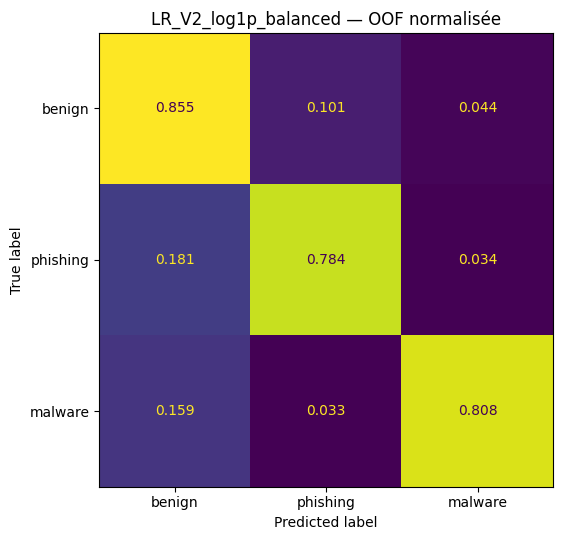

=== HGB_raw_balanced ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.960900,0.032297,0.006803
true_phishing,0.168005,0.822634,0.009362
true_malware,0.220352,0.072287,0.707362


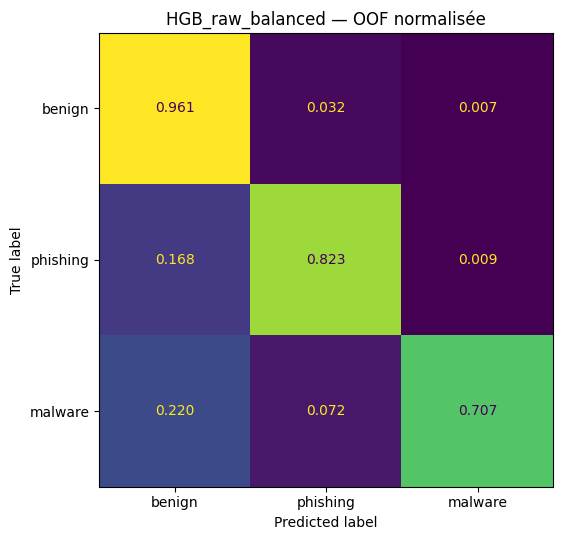

=== HGB_log1p_balanced ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.960900,0.032297,0.006803
true_phishing,0.168005,0.822634,0.009362
true_malware,0.220352,0.072287,0.707362


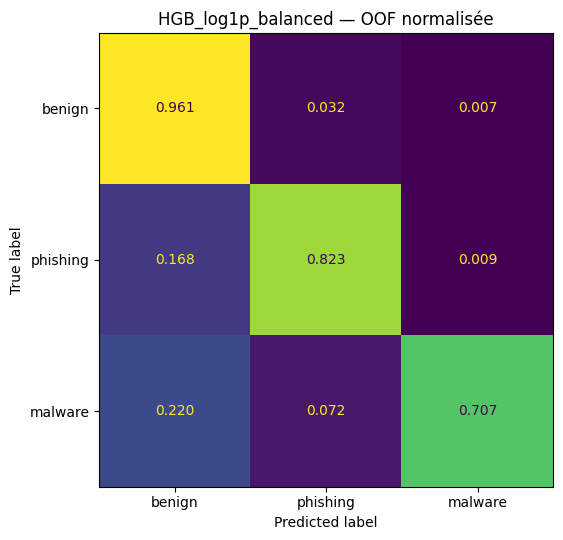

=== ExtraTrees_raw_balanced ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.958368,0.039035,0.002597
true_phishing,0.135595,0.861461,0.002944
true_malware,0.343559,0.018456,0.637985


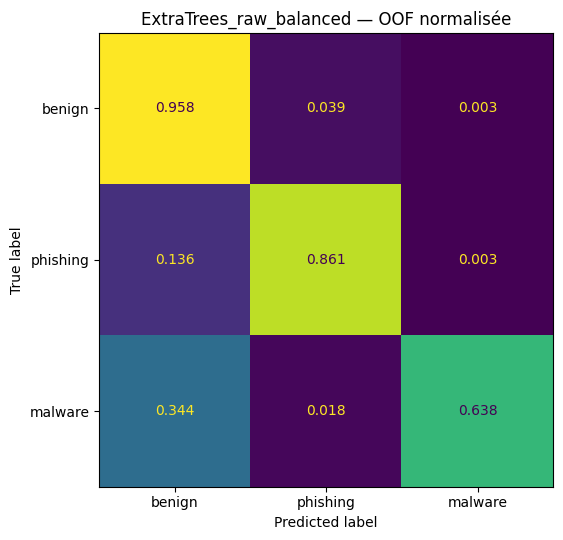

=== ExtraTrees_log1p_balanced ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.957853,0.039100,0.003047
true_phishing,0.163450,0.833514,0.003036
true_malware,0.343227,0.017251,0.639523


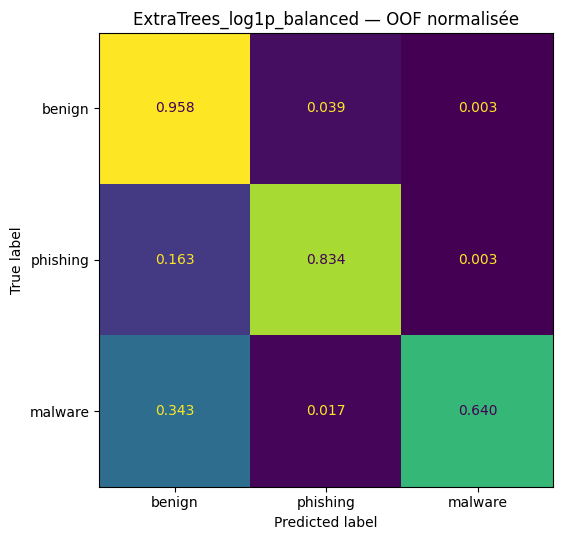

In [29]:
for config_name in (
    MODEL_CONFIGS
):
    matrix = (
        oof_confusions[
            config_name
        ]
    )

    matrix_df = pd.DataFrame(
        matrix,
        index=[
            f"true_{label}"
            for label
            in LABEL_ORDER
        ],
        columns=[
            f"pred_{label}"
            for label
            in LABEL_ORDER
        ],
    )

    print(
        f"=== {config_name} ==="
    )

    display(
        matrix_df
        .round(
            6
        )
    )

    fig, ax = plt.subplots(
        figsize=(
            6.5,
            5.5,
        )
    )

    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=LABEL_ORDER,
    ).plot(
        ax=ax,
        colorbar=False,
        values_format=".3f",
    )

    ax.set_title(
        f"{config_name} — OOF normalisée"
    )

    plt.tight_layout()
    plt.show()

# Partie IX — Comparaisons directes

## 19. Gain par rapport à LR-V2

Chaque nouvelle configuration est comparée fold par fold à LR-V2.

Nous calculons notamment :

- delta macro-F1 ;
- delta balanced accuracy ;
- delta F1 phishing ;
- delta recall phishing.

Une nouvelle famille ne sera considérée supérieure que si le gain est cohérent sur plusieurs folds.

In [30]:
REFERENCE_CONFIG = (
    "LR_V2_log1p_balanced"
)

comparison_rows = []

for config_name in (
    MODEL_CONFIGS
):
    if (
        config_name
        == REFERENCE_CONFIG
    ):
        continue

    candidate_global = (
        fold_metrics_df
        .loc[
            config_name
        ]
        .sort_index()
    )

    reference_global = (
        fold_metrics_df
        .loc[
            REFERENCE_CONFIG
        ]
        .sort_index()
    )

    candidate_phishing = (
        phishing_fold_metrics
        .loc[
            config_name
        ]
        .sort_index()
    )

    reference_phishing = (
        phishing_fold_metrics
        .loc[
            REFERENCE_CONFIG
        ]
        .sort_index()
    )

    for fold_id in (
        candidate_global.index
    ):
        comparison_rows.append(
            {
                "configuration": (
                    config_name
                ),
                "fold_id": int(
                    fold_id
                ),
                "delta_macro_f1": float(
                    candidate_global.loc[
                        fold_id,
                        "f1_macro",
                    ]
                    - reference_global.loc[
                        fold_id,
                        "f1_macro",
                    ]
                ),
                "delta_balanced_accuracy": float(
                    candidate_global.loc[
                        fold_id,
                        "balanced_accuracy",
                    ]
                    - reference_global.loc[
                        fold_id,
                        "balanced_accuracy",
                    ]
                ),
                "delta_phishing_f1": float(
                    candidate_phishing.loc[
                        fold_id,
                        "f1",
                    ]
                    - reference_phishing.loc[
                        fold_id,
                        "f1",
                    ]
                ),
                "delta_phishing_recall": float(
                    candidate_phishing.loc[
                        fold_id,
                        "recall",
                    ]
                    - reference_phishing.loc[
                        fold_id,
                        "recall",
                    ]
                ),
            }
        )


vs_lr_deltas_df = (
    pd.DataFrame(
        comparison_rows
    )
    .set_index(
        [
            "configuration",
            "fold_id",
        ]
    )
)

display(
    vs_lr_deltas_df
    .round(
        6
    )
)

delta_macro_f1  delta_balanced_accuracy  delta_phishing_f1  delta_phishing_recall
configuration             fold_id                                                                                   
HGB_raw_balanced          0              0.030247                 0.020895           0.124598               0.120343
                          1              0.091686                 0.077773           0.071764               0.057614
                          2              0.128009                 0.113908           0.170553               0.217977
                          3             -0.027449                -0.014624           0.009749               0.036762
                          4              0.005437                -0.009738          -0.079089              -0.165116
HGB_log1p_balanced        0              0.030247                 0.020895           0.124598               0.120343
                          1              0.091686                 0.077773           0.071764               0.057614
                          2              0.128009                 0.113908           0.170553               0.217977
                          3             -0.027449                -0.014624           0.009749               0.036762
                          4              0.005437                -0.009738          -0.079089              -0.165116
ExtraTrees_raw_balanced   0              0.026907                 0.016353           0.123674               0.117155
                          1              0.091621                 0.069015           0.068579               0.056008
                          2              0.104416                 0.081123           0.149894               0.190078
                          3             -0.090173                -0.066605           0.051226               0.028314
                          4              0.073591                 0.049021           0.050421               0.036824
ExtraTrees_log1p_balanced 0              0.027276                 0.016761           0.124703               0.118151
                          1              0.091854                 0.069573           0.069554               0.057400
                          2              0.106280                 0.083045           0.153428               0.195415
                          3             -0.088709                -0.065663           0.052205               0.028407
                          4              0.029654                 0.006789          -0.028194              -0.089685

In [31]:
vs_lr_summary = (
    vs_lr_deltas_df
    .groupby(
        level="configuration"
    )
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

display(
    vs_lr_summary
    .round(
        6
    )
)

delta_macro_f1                               delta_balanced_accuracy                               delta_phishing_f1                               delta_phishing_recall                      \
                                    mean       std       min       max                    mean       std       min       max              mean       std       min       max                  mean       std       min   
configuration                                                                                                                                                                                                            
ExtraTrees_log1p_balanced       0.033271  0.076958 -0.088709  0.106280                0.022101  0.059020 -0.065663  0.083045          0.074339  0.070387 -0.028194  0.153428              0.061938  0.106196 -0.089685   
ExtraTrees_raw_balanced         0.041272  0.079137 -0.090173  0.104416                0.029781  0.059195 -0.066605  0.081123          0.088759  0.045394  0.050421  0.149894              0.085676  0.067911  0.028314   
HGB_log1p_balanced              0.045586  0.063443 -0.027449  0.128009                0.037643  0.056312 -0.014624  0.113908          0.059515  0.097984 -0.079089  0.170553              0.053516  0.141077 -0.165116   
HGB_raw_balanced                0.045586  0.063443 -0.027449  0.128009                0.037643  0.056312 -0.014624  0.113908          0.059515  0.097984 -0.079089  0.170553              0.053516  0.141077 -0.165116   

                                     
                                max  
configuration                        
ExtraTrees_log1p_balanced  0.195415  
ExtraTrees_raw_balanced    0.190078  
HGB_log1p_balanced         0.217977  
HGB_raw_balanced           0.217977

## 20. Effet de log1p dans les familles arbres

Nous comparons :

- `HGB-LOG - HGB-RAW` ;
- `ET-LOG - ET-RAW`.

Cette analyse ne cherche pas à réoptimiser `log1p`.

Elle vérifie seulement si la transformation validée pour Logistic Regression reste utile, neutre ou nuisible pour les modèles arbres.

In [32]:
RAW_LOG_PAIRS = {
    "HGB_log_minus_raw": (
        "HGB_log1p_balanced",
        "HGB_raw_balanced",
    ),
    "ExtraTrees_log_minus_raw": (
        "ExtraTrees_log1p_balanced",
        "ExtraTrees_raw_balanced",
    ),
}

raw_log_rows = []

for (
    comparison_name,
    (
        log_config,
        raw_config,
    ),
) in RAW_LOG_PAIRS.items():
    log_metrics = (
        fold_metrics_df
        .loc[
            log_config
        ]
        .sort_index()
    )

    raw_metrics = (
        fold_metrics_df
        .loc[
            raw_config
        ]
        .sort_index()
    )

    log_phishing = (
        phishing_fold_metrics
        .loc[
            log_config
        ]
        .sort_index()
    )

    raw_phishing = (
        phishing_fold_metrics
        .loc[
            raw_config
        ]
        .sort_index()
    )

    for fold_id in (
        log_metrics.index
    ):
        raw_log_rows.append(
            {
                "comparison": (
                    comparison_name
                ),
                "fold_id": int(
                    fold_id
                ),
                "delta_macro_f1": float(
                    log_metrics.loc[
                        fold_id,
                        "f1_macro",
                    ]
                    - raw_metrics.loc[
                        fold_id,
                        "f1_macro",
                    ]
                ),
                "delta_phishing_f1": float(
                    log_phishing.loc[
                        fold_id,
                        "f1",
                    ]
                    - raw_phishing.loc[
                        fold_id,
                        "f1",
                    ]
                ),
                "delta_phishing_recall": float(
                    log_phishing.loc[
                        fold_id,
                        "recall",
                    ]
                    - raw_phishing.loc[
                        fold_id,
                        "recall",
                    ]
                ),
            }
        )


raw_log_deltas_df = (
    pd.DataFrame(
        raw_log_rows
    )
    .set_index(
        [
            "comparison",
            "fold_id",
        ]
    )
)

display(
    raw_log_deltas_df
    .round(
        6
    )
)

display(
    raw_log_deltas_df
    .groupby(
        level="comparison"
    )
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
    .round(
        6
    )
)

delta_macro_f1  delta_phishing_f1  delta_phishing_recall
comparison               fold_id                                                          
HGB_log_minus_raw        0              0.000000           0.000000               0.000000
                         1              0.000000           0.000000               0.000000
                         2              0.000000           0.000000               0.000000
                         3              0.000000           0.000000               0.000000
                         4              0.000000           0.000000               0.000000
ExtraTrees_log_minus_raw 0              0.000369           0.001029               0.000996
                         1              0.000233           0.000975               0.001392
                         2              0.001864           0.003534               0.005337
                         3              0.001464           0.000979               0.000093
                         4             -0.043937          -0.078615              -0.126510

delta_macro_f1                               delta_phishing_f1                               delta_phishing_recall                             
                                   mean       std       min       max              mean       std       min       max                  mean       std      min       max
comparison                                                                                                                                                              
ExtraTrees_log_minus_raw      -0.008001  0.020101 -0.043937  0.001864          -0.01442  0.035903 -0.078615  0.003534             -0.023738  0.057486 -0.12651  0.005337
HGB_log_minus_raw              0.000000  0.000000  0.000000  0.000000           0.00000  0.000000  0.000000  0.000000              0.000000  0.000000  0.00000  0.000000

# Partie X — Stabilité et coût

## 21. Stabilité des modèles

Nous visualisons le macro-F1 et le recall phishing fold par fold.

Un modèle qui domine uniquement sur un fold favorable ne doit pas remplacer LR-V2.

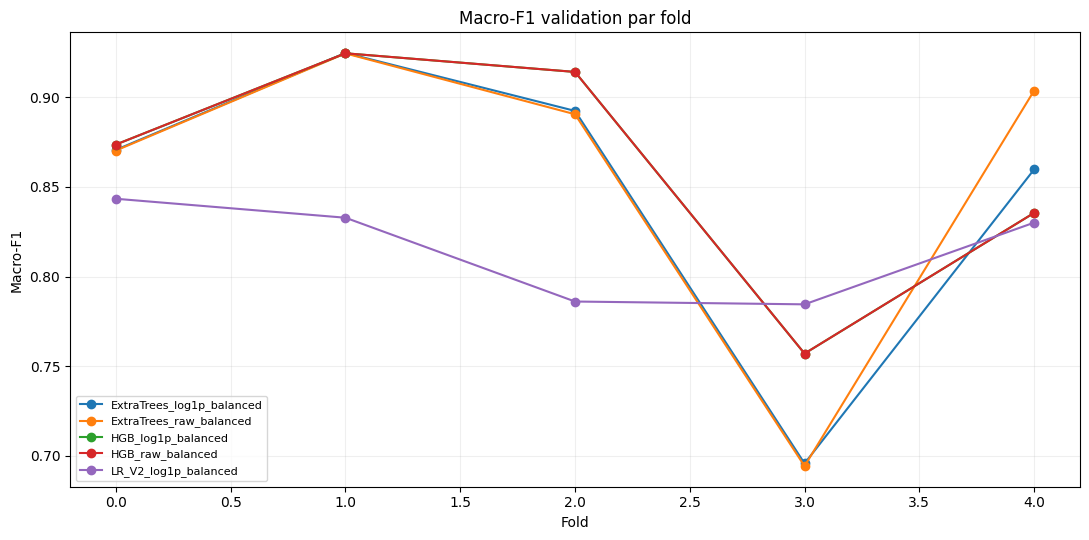

In [33]:
macro_plot_df = (
    fold_metrics_df[
        "f1_macro"
    ]
    .unstack(
        level="configuration"
    )
)

fig, ax = plt.subplots(
    figsize=(
        11,
        5.5,
    )
)

for column in (
    macro_plot_df.columns
):
    ax.plot(
        macro_plot_df.index,
        macro_plot_df[
            column
        ],
        marker="o",
        label=column,
    )

ax.set_title(
    "Macro-F1 validation par fold"
)
ax.set_xlabel(
    "Fold"
)
ax.set_ylabel(
    "Macro-F1"
)
ax.legend(
    fontsize=8
)
ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

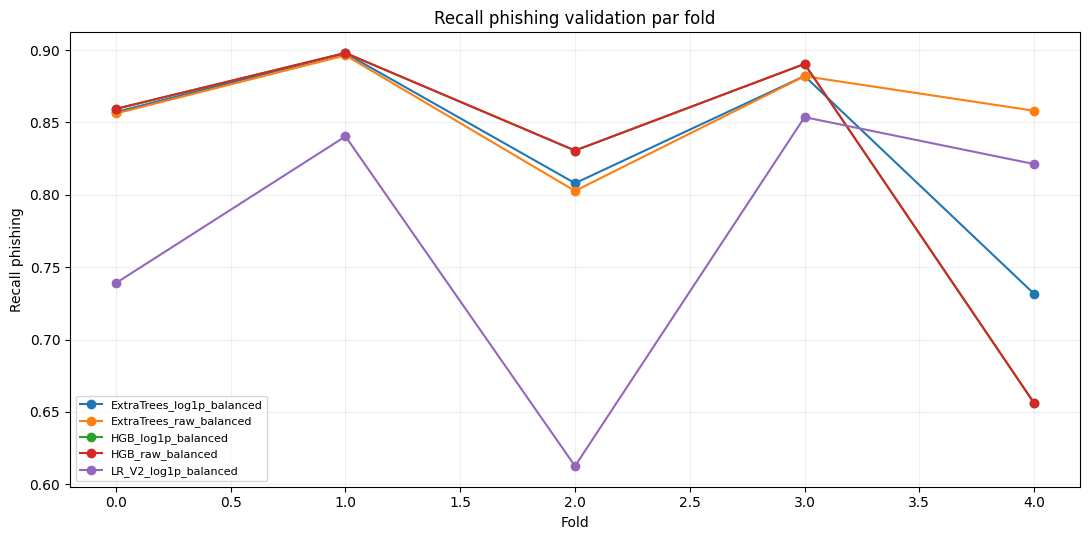

In [34]:
phishing_recall_plot_df = (
    phishing_fold_metrics[
        "recall"
    ]
    .unstack(
        level="configuration"
    )
)

fig, ax = plt.subplots(
    figsize=(
        11,
        5.5,
    )
)

for column in (
    phishing_recall_plot_df.columns
):
    ax.plot(
        phishing_recall_plot_df.index,
        phishing_recall_plot_df[
            column
        ],
        marker="o",
        label=column,
    )

ax.set_title(
    "Recall phishing validation par fold"
)
ax.set_xlabel(
    "Fold"
)
ax.set_ylabel(
    "Recall phishing"
)
ax.legend(
    fontsize=8
)
ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

## 22. Temps de fit et d'inférence

La qualité prédictive n'est pas le seul critère.

Pour notre plateforme, un gain faible ne justifie pas un modèle beaucoup plus coûteux.

Nous comparons donc :

- temps de fit moyen ;
- temps d'inférence moyen ;
- maximum observé ;
- warnings éventuels.

In [35]:
runtime_summary = (
    runtime_df
    .groupby(
        level="configuration"
    )
    .agg(
        {
            "fit_seconds": [
                "mean",
                "std",
                "max",
            ],
            "inference_seconds": [
                "mean",
                "std",
                "max",
            ],
            "iterations": [
                "mean",
                "max",
            ],
            "convergence_warning_count": [
                "sum",
                "max",
            ],
        }
    )
)

display(
    runtime_summary
    .round(
        6
    )
)

fit_seconds                     inference_seconds                     iterations        convergence_warning_count    
                                 mean       std       max              mean       std       max       mean    max                       sum max
configuration                                                                                                                                  
ExtraTrees_log1p_balanced    3.924268  0.361062  4.380735          0.473846  0.029230  0.519207        NaN    NaN                         0   0
ExtraTrees_raw_balanced      4.381682  0.686151  5.462824          0.468299  0.070486  0.568833        NaN    NaN                         0   0
HGB_log1p_balanced           4.047259  0.858949  5.574233          0.680069  0.265043  1.131659      100.0  100.0                         0   0
HGB_raw_balanced             4.307325  1.521994  7.007842          0.574438  0.081323  0.714598      100.0  100.0                         0   0
LR_V2_log1p_balanced         3.408950  1.193290  5.399977          0.026195  0.004873  0.033527       96.8  117.0                         0   0

# Partie XI — Table de décision

## 23. Résumé opérationnel

La décision finale doit intégrer simultanément :

- macro-F1 CV ;
- stabilité ;
- F1/recall phishing ;
- taux phishing → benign ;
- F1 malware ;
- qualité probabiliste ;
- coût de fit/inférence.

Un modèle non linéaire ne remplacera LR-V2 que s'il apporte un gain suffisamment clair pour justifier sa complexité supplémentaire.

In [36]:
decision_rows = []

phishing_index = (
    LABEL_ORDER.index(
        "phishing"
    )
)

benign_index = (
    LABEL_ORDER.index(
        "benign"
    )
)

for config_name in (
    MODEL_CONFIGS
):
    global_fold = (
        fold_metrics_df
        .loc[
            config_name
        ]
    )

    phishing_fold = (
        phishing_fold_metrics
        .loc[
            config_name
        ]
    )

    confusion = (
        oof_confusions[
            config_name
        ]
    )

    oof_benign = (
        oof_class_df.loc[
            (
                config_name,
                "benign",
            )
        ]
    )

    oof_phishing = (
        oof_class_df.loc[
            (
                config_name,
                "phishing",
            )
        ]
    )

    oof_malware = (
        oof_class_df.loc[
            (
                config_name,
                "malware",
            )
        ]
    )

    decision_rows.append(
        {
            "configuration": (
                config_name
            ),
            "family": (
                MODEL_CONFIGS[
                    config_name
                ][
                    "family"
                ]
            ),
            "cv_macro_f1_mean": float(
                global_fold[
                    "f1_macro"
                ].mean()
            ),
            "cv_macro_f1_std": float(
                global_fold[
                    "f1_macro"
                ].std(
                    ddof=1
                )
            ),
            "cv_balanced_accuracy_mean": float(
                global_fold[
                    "balanced_accuracy"
                ].mean()
            ),
            "cv_phishing_f1_mean": float(
                phishing_fold[
                    "f1"
                ].mean()
            ),
            "cv_phishing_recall_mean": float(
                phishing_fold[
                    "recall"
                ].mean()
            ),
            "oof_macro_f1": float(
                oof_global_df.loc[
                    config_name,
                    "f1_macro",
                ]
            ),
            "oof_f1_benign": float(
                oof_benign[
                    "f1"
                ]
            ),
            "oof_f1_phishing": float(
                oof_phishing[
                    "f1"
                ]
            ),
            "oof_f1_malware": float(
                oof_malware[
                    "f1"
                ]
            ),
            "oof_phishing_to_benign": float(
                confusion[
                    phishing_index,
                    benign_index,
                ]
            ),
            "oof_log_loss": float(
                oof_global_df.loc[
                    config_name,
                    "log_loss",
                ]
            ),
            "fit_seconds_mean": float(
                runtime_df
                .loc[
                    config_name,
                    "fit_seconds",
                ]
                .mean()
            ),
            "inference_seconds_mean": float(
                runtime_df
                .loc[
                    config_name,
                    "inference_seconds",
                ]
                .mean()
            ),
        }
    )


decision_table = (
    pd.DataFrame(
        decision_rows
    )
    .set_index(
        "configuration"
    )
    .sort_values(
        [
            "cv_macro_f1_mean",
            "cv_phishing_f1_mean",
        ],
        ascending=[
            False,
            False,
        ],
    )
)

display(
    decision_table
    .round(
        6
    )
)

,family,cv_macro_f1_mean,cv_macro_f1_std,cv_balanced_accuracy_mean,cv_phishing_f1_mean,cv_phishing_recall_mean,oof_macro_f1,oof_f1_benign,oof_f1_phishing,oof_f1_malware,oof_phishing_to_benign,oof_log_loss,fit_seconds_mean,inference_seconds_mean
configuration,,,,,,,,,,,,,,
HGB_raw_balanced,HistGradientBoosting,0.860979,0.067938,0.858426,0.868059,0.826859,0.847563,0.861253,0.867185,0.814249,0.168005,0.359348,4.307325,0.574438
HGB_log1p_balanced,HistGradientBoosting,0.860979,0.067938,0.858426,0.868059,0.826859,0.847563,0.861253,0.867185,0.814249,0.168005,0.359348,4.047259,0.680069
ExtraTrees_raw_balanced,ExtraTrees,0.856665,0.092843,0.850564,0.897303,0.859019,0.840589,0.847275,0.900397,0.774096,0.135595,0.810836,4.381682,0.468299
ExtraTrees_log1p_balanced,ExtraTrees,0.848664,0.088962,0.842884,0.882884,0.835280,0.832194,0.837453,0.884379,0.774751,0.163450,0.844846,3.924268,0.473846
LR_V2_log1p_balanced,LogisticRegression,0.815393,0.027901,0.820783,0.808544,0.773343,0.819447,0.811542,0.820873,0.825925,0.181415,0.488073,3.408950,0.026195


## 24. Résumé automatique

Cette cellule identifie le meilleur score observé mais ne remplace pas l'interprétation.

Nous vérifierons ensemble si :

- le gain est réel sur plusieurs folds ;
- phishing s'améliore ;
- malware reste solide ;
- le coût reste acceptable ;
- raw ou log1p est préférable pour chaque famille.

In [37]:
best_configuration = str(
    decision_table.index[
        0
    ]
)

best_family = str(
    decision_table.loc[
        best_configuration,
        "family",
    ]
)

summary = pd.Series(
    {
        "best_configuration_by_cv_macro_f1": (
            best_configuration
        ),
        "best_family": (
            best_family
        ),
        "best_cv_macro_f1_mean": float(
            decision_table.loc[
                best_configuration,
                "cv_macro_f1_mean",
            ]
        ),
        "best_cv_macro_f1_std": float(
            decision_table.loc[
                best_configuration,
                "cv_macro_f1_std",
            ]
        ),
        "best_cv_phishing_f1_mean": float(
            decision_table.loc[
                best_configuration,
                "cv_phishing_f1_mean",
            ]
        ),
        "best_cv_phishing_recall_mean": float(
            decision_table.loc[
                best_configuration,
                "cv_phishing_recall_mean",
            ]
        ),
        "best_oof_phishing_to_benign": float(
            decision_table.loc[
                best_configuration,
                "oof_phishing_to_benign",
            ]
        ),
        "lr_v2_cv_macro_f1_mean": float(
            decision_table.loc[
                "LR_V2_log1p_balanced",
                "cv_macro_f1_mean",
            ]
        ),
        "delta_best_vs_lr_cv_macro_f1": float(
            decision_table.loc[
                best_configuration,
                "cv_macro_f1_mean",
            ]
            - decision_table.loc[
                "LR_V2_log1p_balanced",
                "cv_macro_f1_mean",
            ]
        ),
        "delta_best_vs_lr_phishing_f1": float(
            decision_table.loc[
                best_configuration,
                "cv_phishing_f1_mean",
            ]
            - decision_table.loc[
                "LR_V2_log1p_balanced",
                "cv_phishing_f1_mean",
            ]
        ),
        "delta_best_vs_lr_phishing_recall": float(
            decision_table.loc[
                best_configuration,
                "cv_phishing_recall_mean",
            ]
            - decision_table.loc[
                "LR_V2_log1p_balanced",
                "cv_phishing_recall_mean",
            ]
        ),
    },
    name="value",
)

display(
    summary.to_frame()
)

,value
best_configuration_by_cv_macro_f1,HGB_raw_balanced
best_family,HistGradientBoosting
best_cv_macro_f1_mean,0.860979
best_cv_macro_f1_std,0.067938
best_cv_phishing_f1_mean,0.868059
best_cv_phishing_recall_mean,0.826859
best_oof_phishing_to_benign,0.168005
lr_v2_cv_macro_f1_mean,0.815393
delta_best_vs_lr_cv_macro_f1,0.045586
delta_best_vs_lr_phishing_f1,0.059515


# Conclusion — Comparaison entre familles de modèles

## 1. Objectif de l'expérience

Après avoir optimisé et validé notre référence linéaire `LR-V2`, l'objectif de cette expérience était de déterminer si une autre famille de modèles pouvait exploiter davantage l'information contenue dans les 13 features lexicales.

Trois familles ont été comparées :

1. Logistic Regression ;
2. HistGradientBoosting ;
3. ExtraTrees.

Cinq configurations ont été évaluées :

| Configuration | Famille | Features | Weighting |
|---|---|---|---|
| LR-V2 | Logistic Regression | log1p | balanced |
| HGB raw | HistGradientBoosting | raw | balanced |
| HGB log1p | HistGradientBoosting | log1p | balanced |
| ExtraTrees raw | ExtraTrees | raw | balanced |
| ExtraTrees log1p | ExtraTrees | log1p | balanced |

Toutes les configurations ont utilisé :

- la même population post-quarantaine ;
- le même train externe ;
- exactement les mêmes 5 folds `StratifiedGroupKFold` ;
- aucun chevauchement de `group_key` ;
- le test externe historique verrouillé ;
- les mêmes métriques ;
- les mêmes règles de calcul OOF.

Le benchmark mesure donc principalement l'effet de la **famille de modèle** et de la représentation raw/log1p.

---

# 2. Résultats globaux

Les principaux résultats de cross-validation sont :

| Configuration | Macro-F1 CV | Std | Balanced Accuracy | F1 phishing | Recall phishing |
|---|---:|---:|---:|---:|---:|
| **HGB raw balanced** | **0.860979** | 0.067938 | **0.858426** | 0.868059 | 0.826859 |
| HGB log1p balanced | **0.860979** | 0.067938 | **0.858426** | 0.868059 | 0.826859 |
| ExtraTrees raw balanced | 0.856665 | 0.092843 | 0.850564 | **0.897303** | **0.859019** |
| ExtraTrees log1p balanced | 0.848664 | 0.088962 | 0.842884 | 0.882884 | 0.835280 |
| LR-V2 | 0.815393 | **0.027901** | 0.820783 | 0.808544 | 0.773343 |

La meilleure performance moyenne est obtenue par :

`HGB_raw_balanced`

avec :

`macro-F1 CV = 0.860979`

contre :

`0.815393`

pour LR-V2.

Le gain moyen est donc :

`+0.045586`

de macro-F1.

Il ne s'agit plus d'une amélioration marginale.

---

# 3. Confirmation de la valeur des modèles non linéaires

HistGradientBoosting et ExtraTrees dépassent tous les deux LR-V2 en performance moyenne.

Cela montre que nos 13 features contiennent des relations que la frontière linéaire de Logistic Regression n'exploite pas complètement.

La limite observée précédemment venait donc en partie de la **nature linéaire du modèle**, et pas uniquement du Feature Set.

Des interactions entre variables et des seuils non linéaires semblent apporter une information prédictive supplémentaire.

---

# 4. HistGradientBoosting : raw et log1p sont équivalents

Un résultat particulièrement propre de cette expérience est que :

`HGB_raw_balanced`

et :

`HGB_log1p_balanced`

produisent exactement les mêmes résultats sur les cinq folds étudiés.

Les deltas observés sont :

- delta macro-F1 : `0.000000` ;
- delta F1 phishing : `0.000000` ;
- delta recall phishing : `0.000000`.

La transformation `log1p`, très utile pour Logistic Regression, n'apporte donc aucun avantage mesurable à HGB dans cette expérience.

### Décision

Pour HistGradientBoosting, nous retenons désormais :

**les 13 features raw.**

Cela simplifie le pipeline :

`raw features → HGB`

sans :

- `log1p` ;
- `StandardScaler`.

---

# 5. Performance OOF

Les macro-F1 OOF sont :

| Configuration | Macro-F1 OOF |
|---|---:|
| **HGB raw** | **0.847563** |
| HGB log1p | **0.847563** |
| ExtraTrees raw | 0.840589 |
| ExtraTrees log1p | 0.832194 |
| LR-V2 | 0.819447 |

La performance consolidée OOF confirme donc le classement observé en cross-validation.

HGB n'est pas seulement performant sur quelques folds : il conserve un avantage global sur LR-V2.

---

# 6. Performance phishing

LR-V2 obtenait en OOF :

- precision : `0.861035` ;
- recall : `0.784290` ;
- F1 : `0.820873`.

HGB raw obtient :

- precision : **`0.916838`** ;
- recall : **`0.822634`** ;
- F1 : **`0.867185`**.

La confusion critique :

`phishing → benign`

passe de :

`18.14 %`

avec LR-V2 à :

**`16.80 %`**

avec HGB.

HGB améliore donc simultanément :

- la precision phishing ;
- le recall phishing ;
- le F1 phishing ;
- le taux de phishing incorrectement considéré comme benign.

Ce résultat constitue un gain métier important pour la plateforme.

---

# 7. Performance benign

HGB améliore également fortement la classe benign.

### LR-V2

- recall : `0.854611` ;
- F1 : `0.811542`.

### HGB raw

- recall : **`0.960900`** ;
- F1 : **`0.861253`**.

Le modèle non linéaire représente donc mieux la frontière entre les URLs benign et les classes malveillantes.

---

# 8. Point faible HGB : malware

La principale faiblesse de HGB apparaît sur le recall malware.

### LR-V2

- precision malware : `0.845167` ;
- recall malware : **`0.807540`** ;
- F1 malware : **`0.825925`**.

### HGB raw

- precision malware : **`0.959191`** ;
- recall malware : `0.707362` ;
- F1 malware : `0.814249`.

HGB devient donc extrêmement précis lorsqu'il prédit malware, mais il attribue cette classe trop rarement.

Il possède une importante marge de precision qui pourrait potentiellement être échangée contre davantage de recall.

La matrice OOF confirme le problème :

### LR-V2

`malware → benign = 15.94 %`

### HGB

`malware → benign = 22.04 %`

Cette dégradation empêche encore HGB d'être considéré comme un modèle final robuste.

---

# 9. ExtraTrees

ExtraTrees raw obtient la meilleure performance phishing :

- F1 phishing CV : `0.897303` ;
- recall phishing CV : `0.859019` ;
- F1 phishing OOF : `0.900397`.

Il réduit également fortement :

`phishing → benign`

jusqu'à environ :

`13.56 %`.

Cependant, ce gain est obtenu avec une forte dégradation malware.

En OOF :

- recall malware : `0.637985` ;
- F1 malware : `0.774096` ;
- malware → benign : **`34.36 %`**.

Plus d'un tiers des malware sont donc classés benign.

Ce compromis n'est pas acceptable pour le modèle principal d'une plateforme Threat Intelligence.

### Décision

ExtraTrees reste une bonne baseline comparative, mais ne sera pas poursuivi comme candidat principal.

---

# 10. Qualité probabiliste

HGB améliore également fortement les métriques probabilistes.

### LR-V2

- log-loss OOF : `0.488073` ;
- ROC-AUC macro : `0.933103` ;
- Average Precision macro : `0.886844` ;
- Brier multiclasses : `0.268500`.

### HGB raw

- log-loss OOF : **`0.359348`** ;
- ROC-AUC macro : **`0.970042`** ;
- Average Precision macro : **`0.948358`** ;
- Brier multiclasses : **`0.201590`**.

Le modèle ne produit donc pas seulement davantage de classifications correctes : le ranking probabiliste des classes est également nettement meilleur.

Une étude dédiée de calibration restera néanmoins nécessaire avant d'interpréter ces probabilités comme des niveaux de confiance opérationnels.

---

# 11. Stabilité inter-folds

Le principal point de prudence est la dispersion entre folds.

### LR-V2

`macro-F1 = 0.815393 ± 0.027901`

### HGB

`macro-F1 = 0.860979 ± 0.067938`

### ExtraTrees raw

`macro-F1 = 0.856665 ± 0.092843`

Les modèles non linéaires sont donc meilleurs en moyenne, mais plus sensibles à la composition des groupes de validation.

HGB améliore LR-V2 sur la majorité des folds, mais pas sur tous.

Les deltas macro-F1 HGB - LR-V2 sont approximativement :

- fold 0 : `+0.0302` ;
- fold 1 : `+0.0917` ;
- fold 2 : `+0.1280` ;
- fold 3 : `-0.0274` ;
- fold 4 : `+0.0054`.

Cela indique que certains groupes restent significativement plus difficiles pour le modèle non linéaire.

Cette variabilité doit être réduite avant de déclarer le modèle final.

---

# 12. Coût computationnel

Les coûts restent raisonnables.

Temps moyen de fit :

- LR-V2 : `~3.41 s` ;
- HGB raw : `~4.31 s` ;
- ExtraTrees raw : `~4.38 s`.

L'inférence HGB est plus lente que Logistic Regression, mais le coût absolu observé reste compatible avec la phase actuelle.

Un benchmark spécifique de latence par observation et par batch sera nécessaire avant intégration production.

---

# 13. Décision sur les familles

Le classement final de cette phase est :

## 1. HistGradientBoosting raw balanced

**Candidate V3**

Raisons :

- meilleur macro-F1 moyen ;
- forte amélioration phishing ;
- forte amélioration benign ;
- meilleure qualité probabiliste ;
- pipeline raw simple ;
- coût raisonnable.

Limites restantes :

- recall malware insuffisant ;
- variance inter-folds supérieure à LR-V2.

---

## 2. Logistic Regression V2

**Référence linéaire / fallback robuste**

Elle reste particulièrement intéressante pour :

- sa stabilité ;
- son recall malware ;
- sa simplicité ;
- sa faible latence.

Elle demeure une excellente référence de comparaison.

---

## 3. ExtraTrees raw

**Baseline comparative uniquement**

Malgré son excellent phishing, la perte malware est trop forte pour justifier sa sélection comme candidat principal.

---

# 14. Candidate V3 retenue

La configuration actuellement retenue est :

`HGB raw balanced`

avec :

- 13 features raw ;
- `HistGradientBoostingClassifier` ;
- `learning_rate=0.1` ;
- `max_iter=100` ;
- `max_leaf_nodes=31` ;
- `min_samples_leaf=20` ;
- `l2_regularization=0.0` ;
- `class_weight="balanced"` ;
- `early_stopping=False` ;
- seed `42`.

Elle devient notre **Candidate V3**, mais pas encore notre modèle final production.

---

# 15. Pourquoi une dernière phase HGB est justifiée

La famille de modèle est désormais sélectionnée.

Il n'est plus utile de multiplier les algorithmes.

La prochaine expérience doit uniquement chercher à améliorer :

1. le recall malware ;
2. la stabilité inter-folds.

Les leviers retenus sont :

- `max_leaf_nodes` ;
- `min_samples_leaf` ;
- `l2_regularization` ;
- learning rate / nombre d'itérations ;
- pondération malware modérément renforcée.

L'objectif n'est pas de maximiser artificiellement le macro-F1.

Nous cherchons un meilleur compromis :

- macro-F1 élevé ;
- phishing solide ;
- malware mieux récupéré ;
- variance réduite ;
- coût raisonnable.

---

# 16. Critères visés pour la prochaine phase

Une variante HGB réellement améliorée devrait idéalement conserver :

- macro-F1 CV `≥ ~0.85` ;
- F1 phishing `≥ ~0.86` ;
- phishing → benign `< 17 %` ;
- F1 malware `≥ ~0.81` ;

tout en rapprochant :

`recall malware`

de :

`~0.78–0.80`

et en réduisant la dispersion actuelle :

`macro-F1 std = 0.0679`.

Si aucune variante simple n'y parvient, le tuning sera arrêté.

La limitation sera alors considérée davantage comme un problème de données/features/groupes que comme un problème d'hyperparamètres.

---

# 17. Limites méthodologiques toujours présentes

Même un HGB amélioré ne supprimera pas les limites du dataset.

En particulier :

- source-label confounding ;
- quarantaine multi-label asymétrique ;
- absence actuelle de validation temporelle finale ;
- absence de sources indépendantes pour chaque classe.

Les résultats actuels démontrent une bonne généralisation inter-groupes dans le dataset disponible.

Ils ne suffisent pas encore à prouver une généralisation vers de nouvelles sources ou de nouvelles périodes.

---

# Conclusion

La comparaison entre familles montre clairement que la non-linéarité apporte une valeur supplémentaire sur notre Feature Set.

`HistGradientBoosting raw balanced`

devient la **Candidate V3**.

Il améliore fortement :

- macro-F1 ;
- benign ;
- phishing ;
- qualité probabiliste.

Cependant, deux limites empêchent encore de le considérer comme modèle final :

- recall malware trop faible ;
- variance inter-folds encore élevée.

La prochaine phase sera donc un **durcissement HGB ciblé**, puis le tuning devra être arrêté au profit d'une validation plus indépendante.

In [38]:
#sauvgarde de modèle HGB candidat
import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import sklearn

from sklearn.ensemble import (
    HistGradientBoostingClassifier,
)


# ============================================================
# Candidate V3 — HGB raw balanced
# ============================================================

MODEL_NAME = (
    "url_multiclass_hist_gradient_boosting_v3_candidate"
)

MODEL_VERSION = (
    "hgb-v3-candidate"
)

MODEL_CONFIGURATION = (
    "HGB_raw_balanced"
)

MODEL_FEATURE_COLUMNS = list(
    RAW_FEATURE_COLUMNS
)


# ============================================================
# 1. Construire le train final
# ============================================================

X_hgb_v3_train = (
    external_train_df[
        MODEL_FEATURE_COLUMNS
    ]
    .astype(float)
)

y_hgb_v3_train = (
    external_train_df[
        "label_code"
    ]
)


if X_hgb_v3_train.isna().any().any():
    raise RuntimeError(
        "NaN détecté dans le train HGB-V3."
    )


if not np.isfinite(
    X_hgb_v3_train.to_numpy(
        dtype=float
    )
).all():
    raise RuntimeError(
        "Valeur non finie détectée "
        "dans le train HGB-V3."
    )


if len(
    MODEL_FEATURE_COLUMNS
) != 13:
    raise RuntimeError(
        "Nombre de features HGB-V3 inattendu."
    )


# ============================================================
# 2. Réentraîner la configuration sélectionnée
#    sur TOUT external_train_df
# ============================================================

hgb_v3_model = (
    HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.1,
        max_iter=100,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.0,
        class_weight="balanced",
        early_stopping=False,
        random_state=RANDOM_SEED,
    )
)


fit_started_at = (
    time.perf_counter()
)

hgb_v3_model.fit(
    X_hgb_v3_train,
    y_hgb_v3_train,
)

fit_seconds = (
    time.perf_counter()
    - fit_started_at
)


print(
    "HGB Candidate V3 entraînée."
)

print(
    "Training rows:",
    len(
        X_hgb_v3_train
    ),
)

print(
    "Features:",
    len(
        MODEL_FEATURE_COLUMNS
    ),
)

print(
    "Iterations:",
    hgb_v3_model.n_iter_,
)

print(
    "Fit seconds:",
    round(
        fit_seconds,
        4,
    ),
)


# ============================================================
# 3. Répertoire artefacts
# ============================================================

MODEL_ARTIFACT_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "ml"
    / "models"
)

MODEL_ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


model_path = (
    MODEL_ARTIFACT_DIR
    / f"{MODEL_NAME}.joblib"
)

metadata_path = (
    MODEL_ARTIFACT_DIR
    / f"{MODEL_NAME}.metadata.json"
)


# ============================================================
# 4. Artefact modèle
# ============================================================

artifact = {
    "artifact_version": (
        MODEL_VERSION
    ),

    "model": (
        hgb_v3_model
    ),

    "feature_columns": list(
        MODEL_FEATURE_COLUMNS
    ),

    "feature_representation": (
        "raw"
    ),

    "label_order": list(
        LABEL_ORDER
    ),

    "probability_label_order": list(
        PROBABILITY_LABEL_ORDER
    ),

    "dataset_name": (
        DATASET_NAME
    ),

    "dataset_version": (
        DATASET_VERSION
    ),

    "feature_set_version": (
        EXPECTED_FEATURE_SET_VERSION
    ),
}


joblib.dump(
    artifact,
    model_path,
    compress=3,
)


# ============================================================
# 5. SHA-256
# ============================================================

def sha256_file(
    path: Path,
) -> str:
    digest = hashlib.sha256()

    with path.open(
        "rb"
    ) as handle:
        for chunk in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(
                chunk
            )

    return digest.hexdigest()


model_sha256 = sha256_file(
    model_path
)


# ============================================================
# 6. Récupérer les métriques validées
# ============================================================

candidate_decision = (
    decision_table.loc[
        MODEL_CONFIGURATION
    ]
)

candidate_oof_global = (
    oof_global_df.loc[
        MODEL_CONFIGURATION
    ]
)

candidate_oof_malware = (
    oof_class_df.loc[
        (
            MODEL_CONFIGURATION,
            "malware",
        )
    ]
)

candidate_oof_phishing = (
    oof_class_df.loc[
        (
            MODEL_CONFIGURATION,
            "phishing",
        )
    ]
)


# ============================================================
# 7. Metadata JSON
# ============================================================

metadata = {
    "model_name": (
        MODEL_NAME
    ),

    "model_version": (
        MODEL_VERSION
    ),

    "status": (
        "candidate"
    ),

    "created_at_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),

    "model_family": (
        "HistGradientBoostingClassifier"
    ),

    "configuration": (
        MODEL_CONFIGURATION
    ),

    "dataset": {
        "name": (
            DATASET_NAME
        ),
        "version": (
            DATASET_VERSION
        ),
        "feature_set_version": (
            EXPECTED_FEATURE_SET_VERSION
        ),
    },

    "features": {
        "representation": (
            "raw"
        ),
        "count": len(
            MODEL_FEATURE_COLUMNS
        ),
        "columns": list(
            MODEL_FEATURE_COLUMNS
        ),
    },

    "training": {
        "rows": int(
            len(
                external_train_df
            )
        ),
        "strategy": (
            "full external train"
        ),
        "external_test_used_for_fit": False,
        "random_seed": (
            RANDOM_SEED
        ),
    },

    "hyperparameters": {
        "loss": (
            "log_loss"
        ),
        "learning_rate": 0.1,
        "max_iter": 100,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 0.0,
        "class_weight": (
            "balanced"
        ),
        "early_stopping": False,
    },

    "selection_protocol": {
        "cv": (
            "StratifiedGroupKFold"
        ),
        "n_splits": 5,
        "group_aware": True,
        "external_test_locked": True,
    },

    "validated_metrics": {
        "cv_macro_f1_mean": float(
            candidate_decision[
                "cv_macro_f1_mean"
            ]
        ),
        "cv_macro_f1_std": float(
            candidate_decision[
                "cv_macro_f1_std"
            ]
        ),
        "cv_balanced_accuracy_mean": float(
            candidate_decision[
                "cv_balanced_accuracy_mean"
            ]
        ),
        "cv_phishing_f1_mean": float(
            candidate_decision[
                "cv_phishing_f1_mean"
            ]
        ),
        "cv_phishing_recall_mean": float(
            candidate_decision[
                "cv_phishing_recall_mean"
            ]
        ),
        "oof_macro_f1": float(
            candidate_oof_global[
                "f1_macro"
            ]
        ),
        "oof_log_loss": float(
            candidate_oof_global[
                "log_loss"
            ]
        ),
        "oof_phishing_f1": float(
            candidate_oof_phishing[
                "f1"
            ]
        ),
        "oof_phishing_recall": float(
            candidate_oof_phishing[
                "recall"
            ]
        ),
        "oof_malware_f1": float(
            candidate_oof_malware[
                "f1"
            ]
        ),
        "oof_malware_recall": float(
            candidate_oof_malware[
                "recall"
            ]
        ),
        "oof_phishing_to_benign": float(
            candidate_decision[
                "oof_phishing_to_benign"
            ]
        ),
    },

    "runtime": {
        "final_fit_seconds": float(
            fit_seconds
        ),
        "n_iter": int(
            hgb_v3_model.n_iter_
        ),
    },

    "environment": {
        "scikit_learn": (
            sklearn.__version__
        ),
    },

    "integrity": {
        "sha256": (
            model_sha256
        ),
    },

    "limitations": [
        (
            "Candidate model, not final production model."
        ),
        (
            "Malware recall remains below LR-V2."
        ),
        (
            "Cross-validation variance remains elevated."
        ),
        (
            "Source-label confounding remains unresolved."
        ),
        (
            "Temporal and independent-source validation "
            "remain required."
        ),
    ],
}


with metadata_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        metadata,
        handle,
        ensure_ascii=False,
        indent=2,
    )


# ============================================================
# 8. Vérification de sérialisation
# ============================================================

loaded_artifact = joblib.load(
    model_path
)

loaded_model = (
    loaded_artifact[
        "model"
    ]
)

loaded_features = (
    loaded_artifact[
        "feature_columns"
    ]
)


if (
    loaded_features
    != MODEL_FEATURE_COLUMNS
):
    raise RuntimeError(
        "Ordre des features modifié "
        "après sérialisation."
    )


sample_check = (
    external_train_df[
        MODEL_FEATURE_COLUMNS
    ]
    .head(
        100
    )
    .astype(float)
)


pred_before = (
    hgb_v3_model.predict(
        sample_check
    )
)

pred_after = (
    loaded_model.predict(
        sample_check
    )
)


if not np.array_equal(
    pred_before,
    pred_after,
):
    raise RuntimeError(
        "Les prédictions diffèrent "
        "après sérialisation."
    )


if (
    sha256_file(
        model_path
    )
    != model_sha256
):
    raise RuntimeError(
        "SHA-256 incohérent après écriture."
    )


print()
print(
    "✓ HGB Candidate V3 sauvegardée"
)

print(
    "✓ Artefact rechargé correctement"
)

print(
    "✓ Features identiques"
)

print(
    "✓ Prédictions identiques"
)

print(
    "✓ SHA-256 vérifié"
)

print()
print(
    "Model:",
    model_path.relative_to(
        PROJECT_ROOT
    ),
)

print(
    "Metadata:",
    metadata_path.relative_to(
        PROJECT_ROOT
    ),
)

print(
    "SHA-256:",
    model_sha256,
)

HGB Candidate V3 entraînée.
Training rows: 114131
Features: 13
Iterations: 100
Fit seconds: 13.5679

✓ HGB Candidate V3 sauvegardée
✓ Artefact rechargé correctement
✓ Features identiques
✓ Prédictions identiques
✓ SHA-256 vérifié

Model: artifacts\ml\models\url_multiclass_hist_gradient_boosting_v3_candidate.joblib
Metadata: artifacts\ml\models\url_multiclass_hist_gradient_boosting_v3_candidate.metadata.json
SHA-256: 2389153ba492f4d5add7169c7aed1a734899959e546ab214799f603874db3722
